# Notebook 0: Exploratory Data Analysis

## Project: Beyond Distributional Similarity — Evaluating Predictive Utility of Synthetic Liver Cirrhosis Data

**Dataset:** Mayo Clinic Primary Biliary Cirrhosis (PBC) Trial  
**Author:** Michael Udousoro

---

## Purpose of this notebook

Before building any generative model or running any classifier, we need a thorough understanding of the raw patient data. This notebook is a complete exploratory data analysis that serves two purposes: it informs every modelling decision made in the subsequent notebooks, and it provides the publication-quality visualisations needed to describe the dataset in the paper.

## What this notebook covers

1. Dataset overview and descriptive statistics  
2. Missing value visualisation  
3. Outcome class distribution  
4. Histograms with KDE for all continuous features  
5. Box plots comparing feature distributions by patient outcome  
6. Violin plots showing full distribution shape by outcome  
7. Correlation matrix for all continuous features  
8. Categorical feature breakdown by outcome  
9. Pairplot of the most clinically relevant features  
10. Outlier profile using the IQR method

## Run this notebook before all others

This notebook reads only the raw CSV and produces no outputs that subsequent notebooks depend on. It is purely for understanding and documentation.

In [1]:
%matplotlib inline

import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats

sys.path.insert(0, os.getcwd())
from src.data_loader import (
    load_complete_data,
    CONTINUOUS_COLS, BINARY_COLS, ORDINAL_COLS, TARGET_COL
)

# Global figure style — clean, publication-ready
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

os.makedirs('output/figures', exist_ok=True)

# Colour scheme used consistently throughout this notebook
COLOR_ALL      = '#505050'   # slate blue — full dataset
COLOR_SURVIVED = '#0099FF'   # blue       — survived / transplant
COLOR_DIED     = '#DC0000'   # pink       — deceased
PALETTE        = [COLOR_SURVIVED, COLOR_DIED]

print('Setup complete. All plots will display inline.')

Setup complete. All plots will display inline.


---

## Section 1: Load the Data

We load both the raw file (to examine missingness) and the cleaned complete-case file (for all subsequent analysis).

In [2]:
# Raw file — includes missing values so we can study them
raw_df = pd.read_csv('data/raw/cirrhosis.csv', na_values=['NA', 'N/A', ''])
if 'ID' in raw_df.columns:
    raw_df = raw_df.drop(columns=['ID'])

# Clean file — complete-case analysis applied, all columns numeric
df = load_complete_data('data/raw/cirrhosis.csv')

# Separate by outcome for side-by-side comparisons
df_survived = df[df[TARGET_COL] == 0]
df_deceased     = df[df[TARGET_COL] == 1]

print(f'Raw dataset:   {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
print(f'Complete cases: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Survived / Transplant: {len(df_survived)} patients')
print(f'Died:                  {len(df_deceased)} patients')

Data loader: 418 total patients in raw file, 276 patients kept after complete-case filter
Raw dataset:   418 rows, 19 columns
Complete cases: 276 rows, 19 columns
Survived / Transplant: 165 patients
Died:                  111 patients


---

## Section 2: Descriptive Statistics

A full statistical summary of every continuous feature. These numbers — means, standard deviations, min/max, and quartiles — form the baseline against which the synthetic data will later be compared.

In [3]:
print('Descriptive statistics for all continuous features (complete cases only):')
print()
df[CONTINUOUS_COLS].describe().T.round(2)

Descriptive statistics for all continuous features (complete cases only):



,count,mean,std,min,25%,50%,75%,max
N_Days,276.0,1979.17,1112.38,41.00,1185.75,1788.00,2689.75,4556.00
Age,276.0,18189.33,3843.56,9598.00,15162.50,18156.50,20667.50,28650.00
Bilirubin,276.0,3.33,4.60,0.30,0.80,1.40,3.52,28.00
Cholesterol,276.0,371.26,234.79,120.00,249.50,310.00,401.00,1775.00
Albumin,276.0,3.52,0.40,1.96,3.31,3.54,3.77,4.40
Copper,276.0,100.77,88.27,4.00,42.75,74.00,129.25,588.00
Alk_Phos,276.0,1996.61,2115.48,289.00,922.50,1277.50,2068.25,13862.40
SGOT,276.0,124.12,56.72,28.38,82.46,116.62,153.45,457.25
Tryglicerides,276.0,124.98,65.28,33.00,85.00,108.00,151.25,598.00
Platelets,276.0,261.77,93.13,62.00,200.00,257.00,318.25,563.00


In [4]:
# Compare means between outcome groups — a first signal of which features
# differ between patients who deceased and those who survived
summary = pd.DataFrame({
    'All patients (mean)':      df[CONTINUOUS_COLS].mean().round(2),
    'Survived (mean)':          df_survived[CONTINUOUS_COLS].mean().round(2),
    'Deceased (mean)':              df_deceased[CONTINUOUS_COLS].mean().round(2),
    'Difference (deceased-survived)':   (df_deceased[CONTINUOUS_COLS].mean() - df_survived[CONTINUOUS_COLS].mean()).round(2),
})
print('Mean values by outcome group:')
summary

Mean values by outcome group:


,All patients (mean),Survived (mean),Deceased (mean),Difference (deceased-survived)
N_Days,1979.17,2295.76,1508.55,-787.21
Age,18189.33,17316.41,19486.91,2170.50
Bilirubin,3.33,1.75,5.68,3.93
Cholesterol,371.26,339.22,418.89,79.67
Albumin,3.52,3.61,3.38,-0.23
Copper,100.77,74.15,140.34,66.20
Alk_Phos,1996.61,1502.01,2731.83,1229.82
SGOT,124.12,112.41,141.52,29.10
Tryglicerides,124.98,113.64,141.84,28.20
Platelets,261.77,270.02,249.51,-20.50


---

## Section 3: Missing Value Visualisation

The heatmap below shows the pattern of missingness across all 418 raw patient records. White cells are missing values. The dense block of white near the bottom of several columns reveals the observational cohort (patients 313 to 418) who were missing most laboratory measurements.

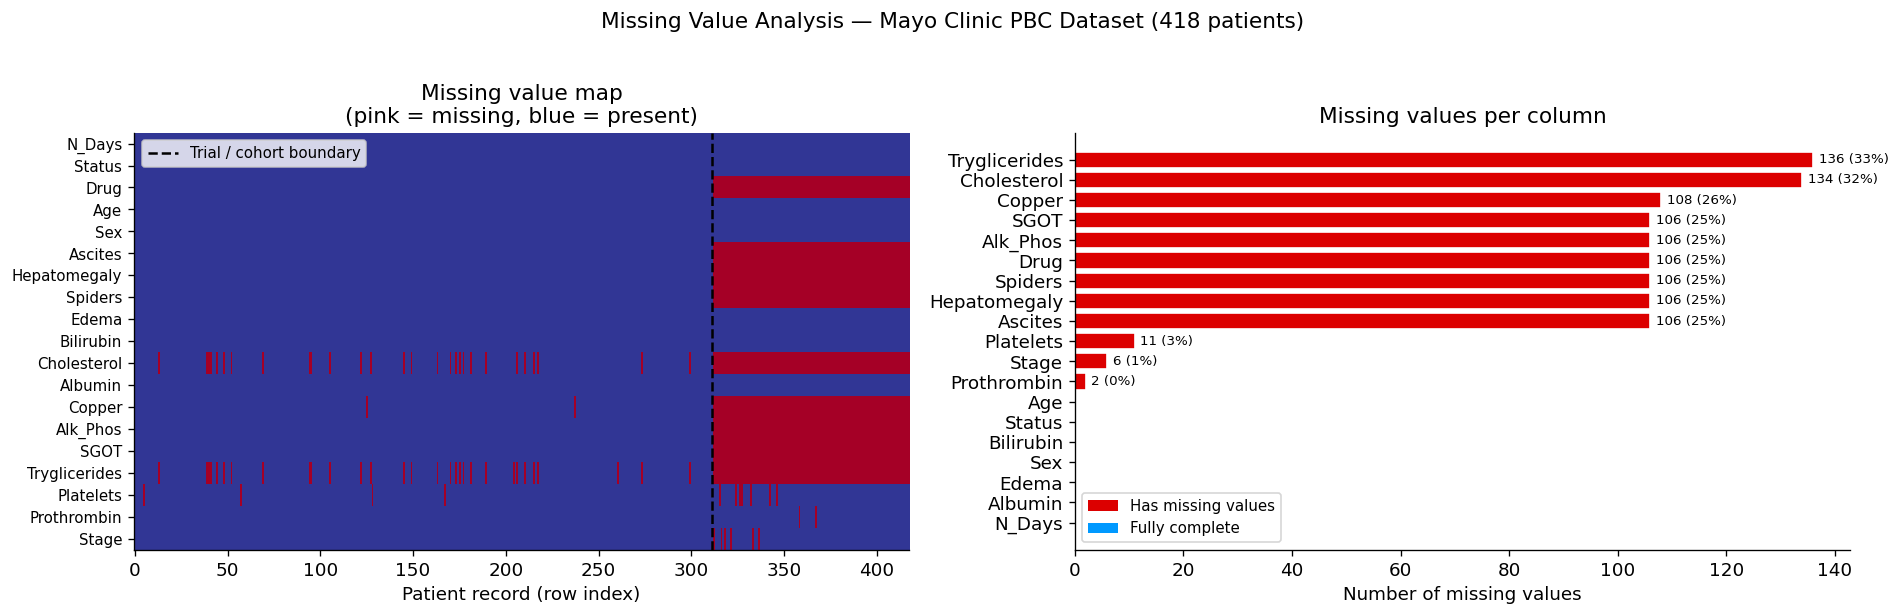

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left panel — missingness heatmap
ax = axes[0]
missing_matrix = raw_df.isnull().astype(int)
im = ax.imshow(missing_matrix.T, aspect='auto', cmap='RdYlBu_r', interpolation='none')
ax.set_yticks(range(len(raw_df.columns)))
ax.set_yticklabels(raw_df.columns, fontsize=9)
ax.set_xlabel('Patient record (row index)')
ax.set_title('Missing value map\n(pink = missing, blue = present)')
ax.axvline(311, color='black', linewidth=1.5, linestyle='--', label='Trial / cohort boundary')
ax.legend(fontsize=9, loc='upper left')

# Right panel — missing count per column
ax2 = axes[1]
missing_counts = raw_df.isnull().sum().sort_values(ascending=True)
colors = [COLOR_DIED if v > 0 else COLOR_SURVIVED for v in missing_counts]
bars = ax2.barh(missing_counts.index, missing_counts.values, color=colors, edgecolor='white')
ax2.set_xlabel('Number of missing values')
ax2.set_title('Missing values per column')
for bar, val in zip(bars, missing_counts.values):
    if val > 0:
        ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(raw_df)*100:.0f}%)', va='center', fontsize=8)
legend_elements = [Patch(facecolor=COLOR_DIED, label='Has missing values'),
                   Patch(facecolor=COLOR_SURVIVED, label='Fully complete')]
ax2.legend(handles=legend_elements, fontsize=9)

plt.suptitle('Missing Value Analysis — Mayo Clinic PBC Dataset (418 patients)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('output/figures/eda_missing_values.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 4: Patient Outcome Distribution

Understanding the class balance is essential. An imbalanced dataset — where one outcome is much more common than the other — can bias classifiers toward the majority class and requires careful handling during both synthetic generation and model evaluation.

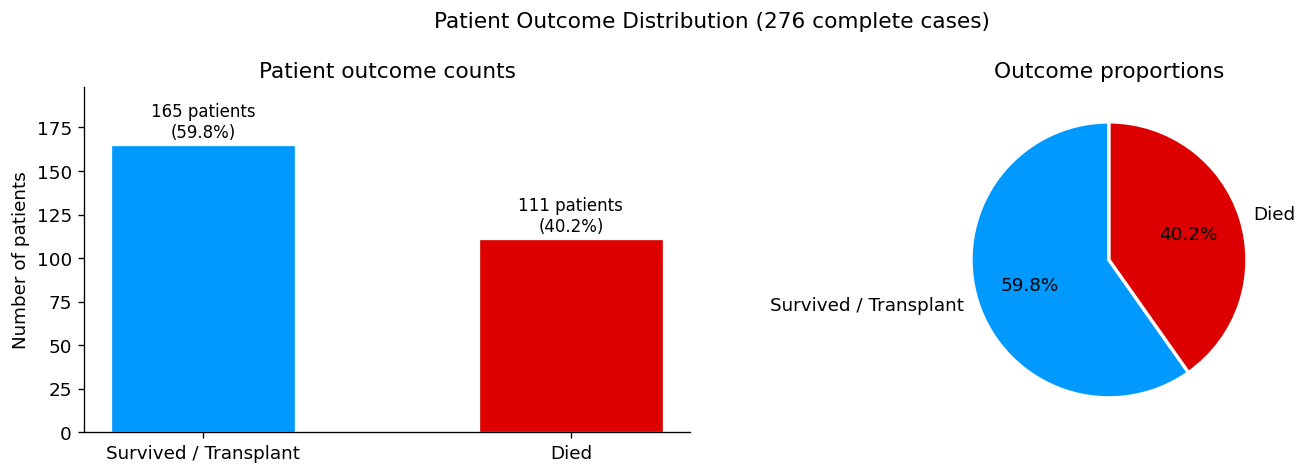

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Survived / Transplant', 'Died']
counts = [len(df_survived), len(df_deceased)]
pcts   = [c / len(df) * 100 for c in counts]

# Bar chart
ax = axes[0]
bars = ax.bar(labels, counts, color=PALETTE, edgecolor='white', linewidth=0.8, width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{count} patients\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of patients')
ax.set_title('Patient outcome counts')
ax.set_ylim(0, max(counts) * 1.2)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, colors=PALETTE,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(11)
ax2.set_title('Outcome proportions')

plt.suptitle('Patient Outcome Distribution (276 complete cases)', fontsize=13)
plt.tight_layout()
plt.savefig('output/figures/eda_outcome_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 5: Side-by-Side Histograms with Distribution Curves

Each feature panel shows two layers of information simultaneously. The bars are placed side by side — blue for survived or transplant patients, red for patients who deceased — so there is no colour overlap between the groups. Each bar is normalised to density so its height is directly comparable to the KDE distribution curve drawn on top.

The curves use a darker shade of each group colour and are drawn as solid (survived) or dashed (deceased) lines so they remain distinguishable even when the two distributions overlap. Together the bars and curves reveal both the exact relative frequency at each value and the smooth underlying distributional shape.


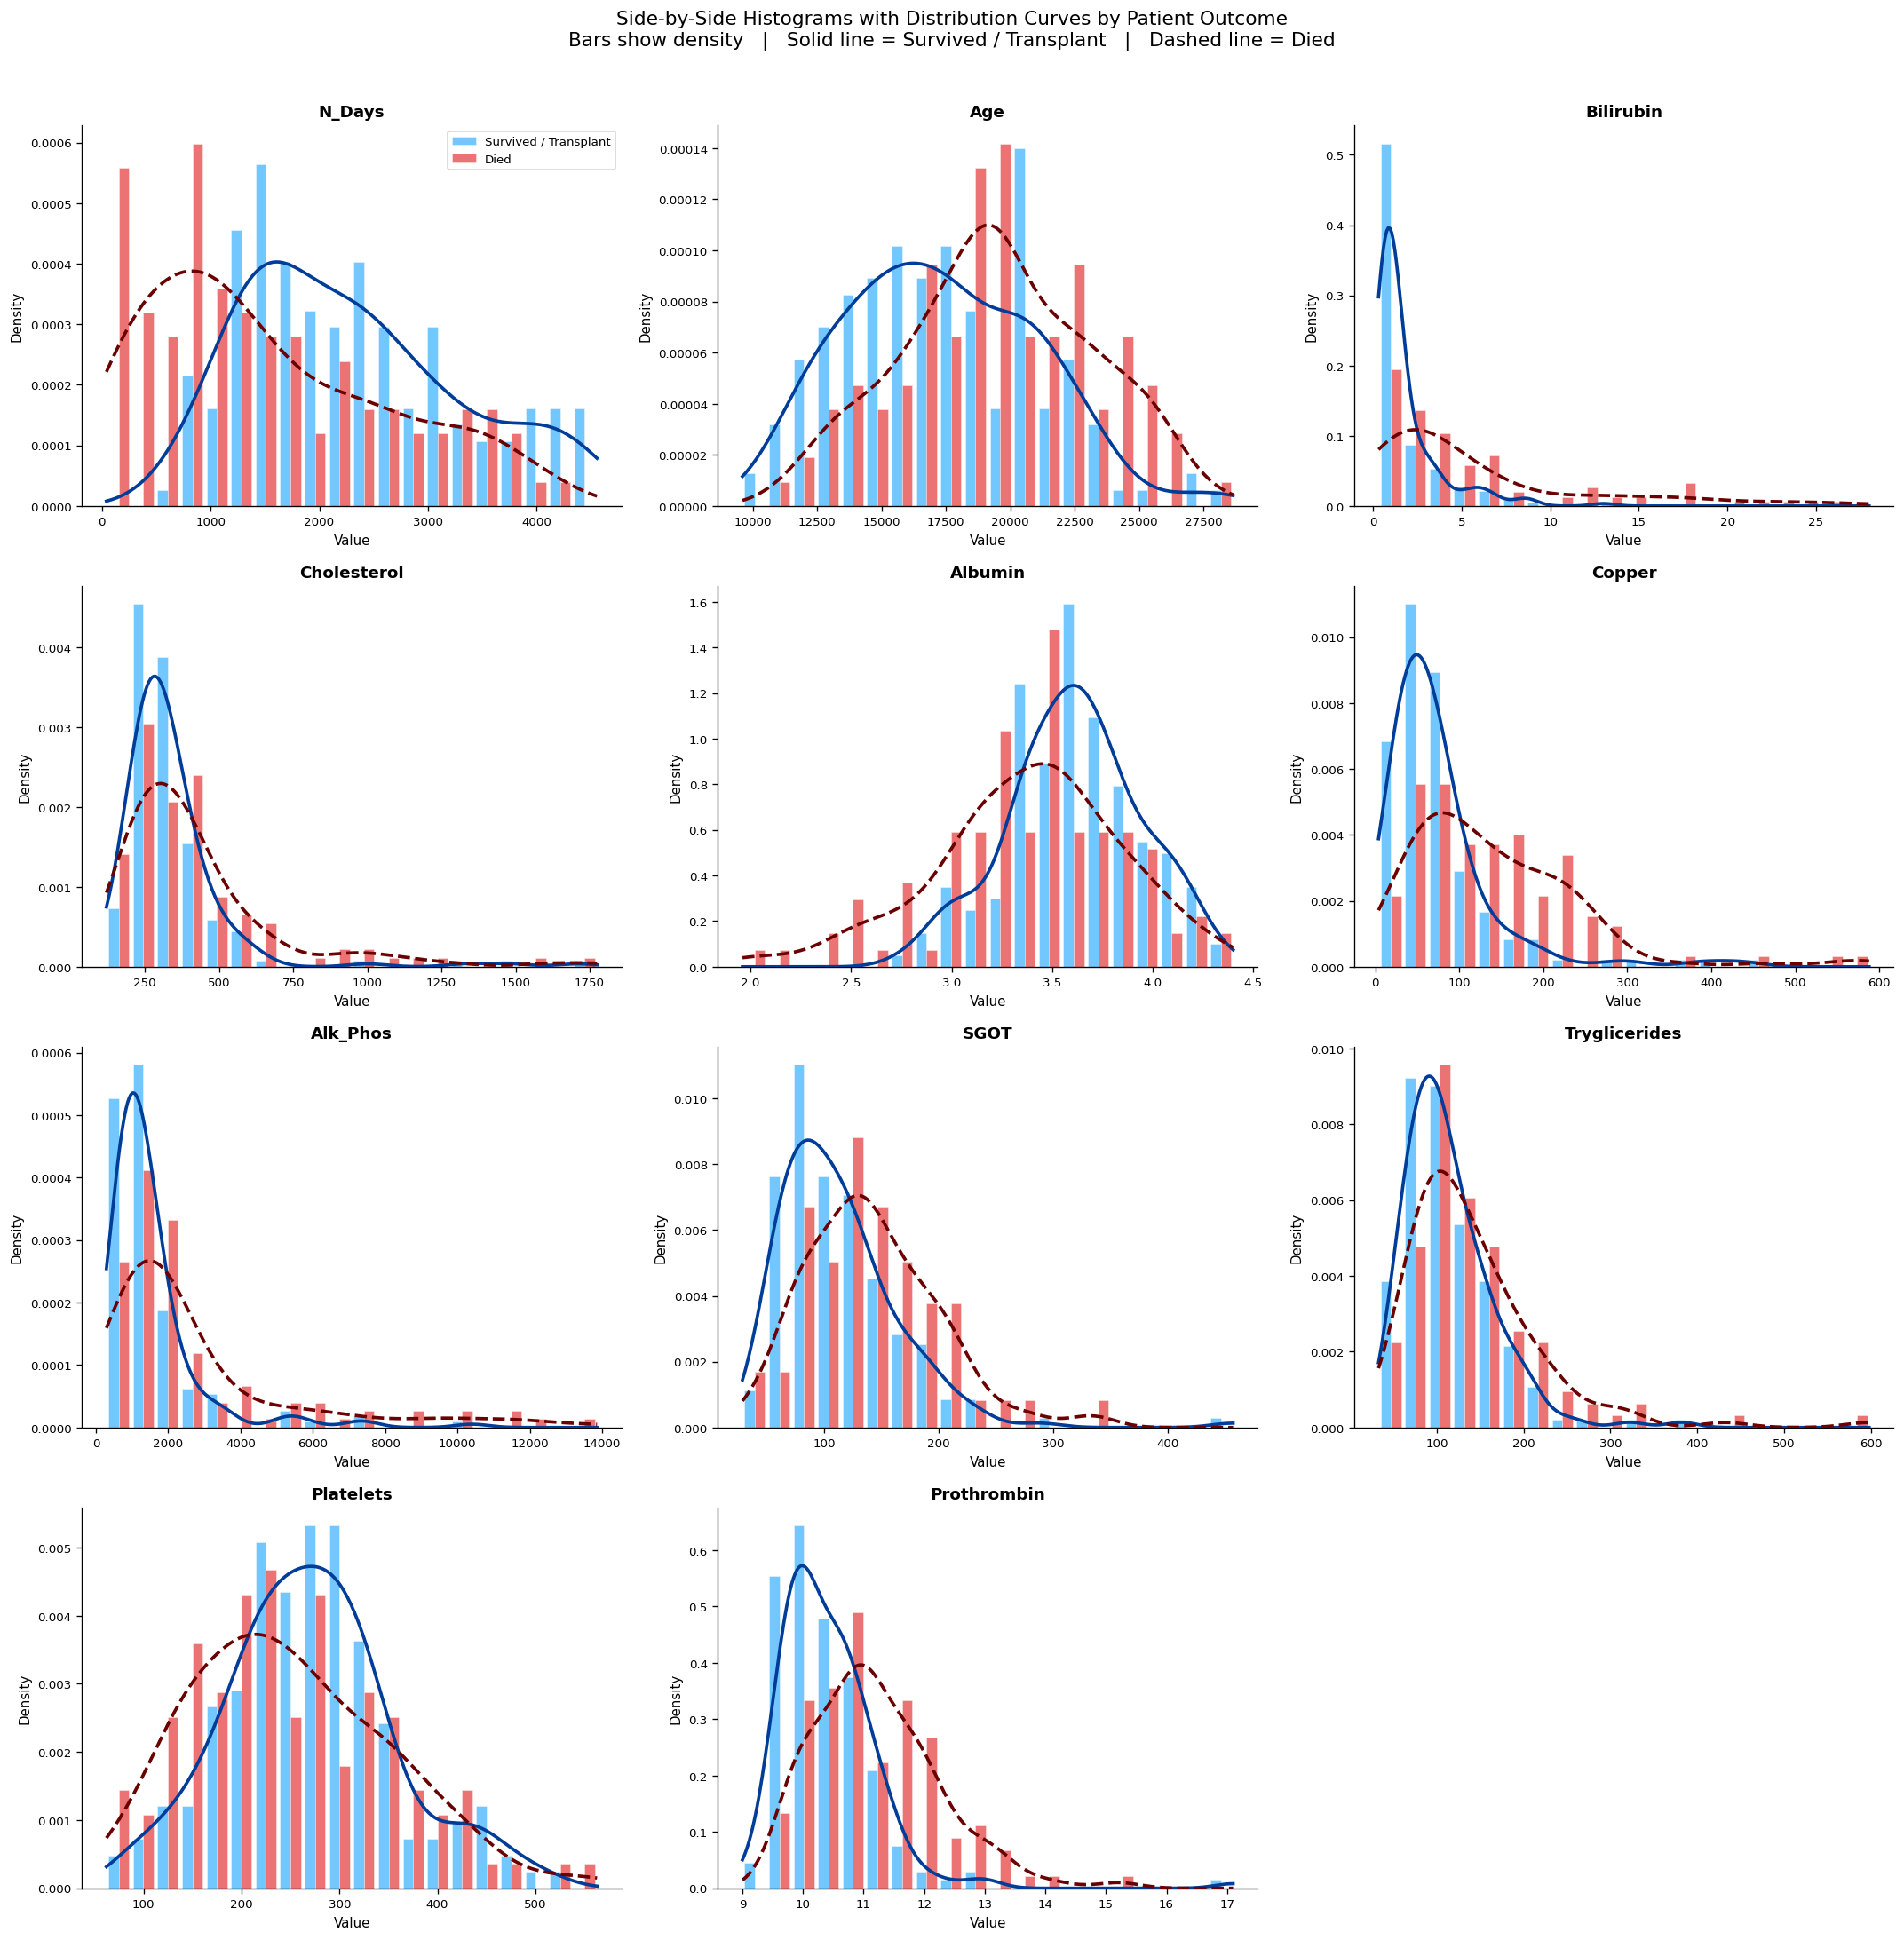

Figure saved.


In [7]:
# Side-by-side bars with KDE curves overlaid.
# The bars are normalised to density so they sit on the same scale as the
# KDE curves. This means you can read the distribution shape from the curves
# while still seeing the exact relative counts from the bar heights.
# Blue = Survived / Transplant.  Red = Died.
# Solid curves use a darker shade of each colour so they stand out clearly
# above the semi-transparent bars beneath them.

N_BINS  = 20
n_cols  = 3
n_rows  = int(np.ceil(len(CONTINUOUS_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

GROUPS = [
    dict(df=df_survived, bar_color='#0099FF', curve_color='#003D99',
         label='Survived / Transplant', side=-1),
    dict(df=df_deceased,     bar_color='#DC0000', curve_color='#6B0000',
         label='Died',                   side=+1),
]

for i, col in enumerate(CONTINUOUS_COLS):
    ax = axes[i]

    # Shared bin edges cover the full combined range of both groups
    all_vals   = df[col].dropna()
    bin_edges  = np.linspace(all_vals.min(), all_vals.max(), N_BINS + 1)
    bin_width  = bin_edges[1] - bin_edges[0]
    bar_width  = bin_width * 0.42
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    for g in GROUPS:
        vals = g['df'][col].dropna()

        # Bars: normalise to density so scale matches the KDE curve
        counts, _ = np.histogram(vals, bins=bin_edges)
        density   = counts / (counts.sum() * bin_width)
        offset    = g['side'] * bar_width / 2

        ax.bar(
            bin_centres + offset, density,
            width=bar_width,
            color=g['bar_color'], alpha=0.55,
            edgecolor='white', linewidth=0.4,
            label=g['label']
        )

        # KDE curve: smooth density estimate drawn as a thick line
        # in a darker shade of the same colour so it is clearly visible
        # above the bars
        kde_x = np.linspace(all_vals.min(), all_vals.max(), 300)
        try:
            kde = stats.gaussian_kde(vals, bw_method=0.35)
            ax.plot(
                kde_x, kde(kde_x),
                color=g['curve_color'],
                linewidth=2.2,
                linestyle='-' if g['side'] == -1 else '--',
                zorder=5
            )
        except Exception:
            pass

    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.tick_params(labelsize=8)

    if i == 0:
        ax.legend(fontsize=8, frameon=True, edgecolor='#cccccc')

for j in range(len(CONTINUOUS_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Side-by-Side Histograms with Distribution Curves by Patient Outcome\n'
    'Bars show density   |   Solid line = Survived / Transplant   |   Dashed line = Died',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('output/figures/eda_histograms_sidebyside.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 6: Box Plots by Patient Outcome

Box plots summarise the median, interquartile range, and extreme values of each feature grouped by patient outcome. Features where the two boxes do not overlap are strong candidates for distinguishing deceased from survived patients. Outliers plotted as individual dots indicate highly skewed feature distributions.

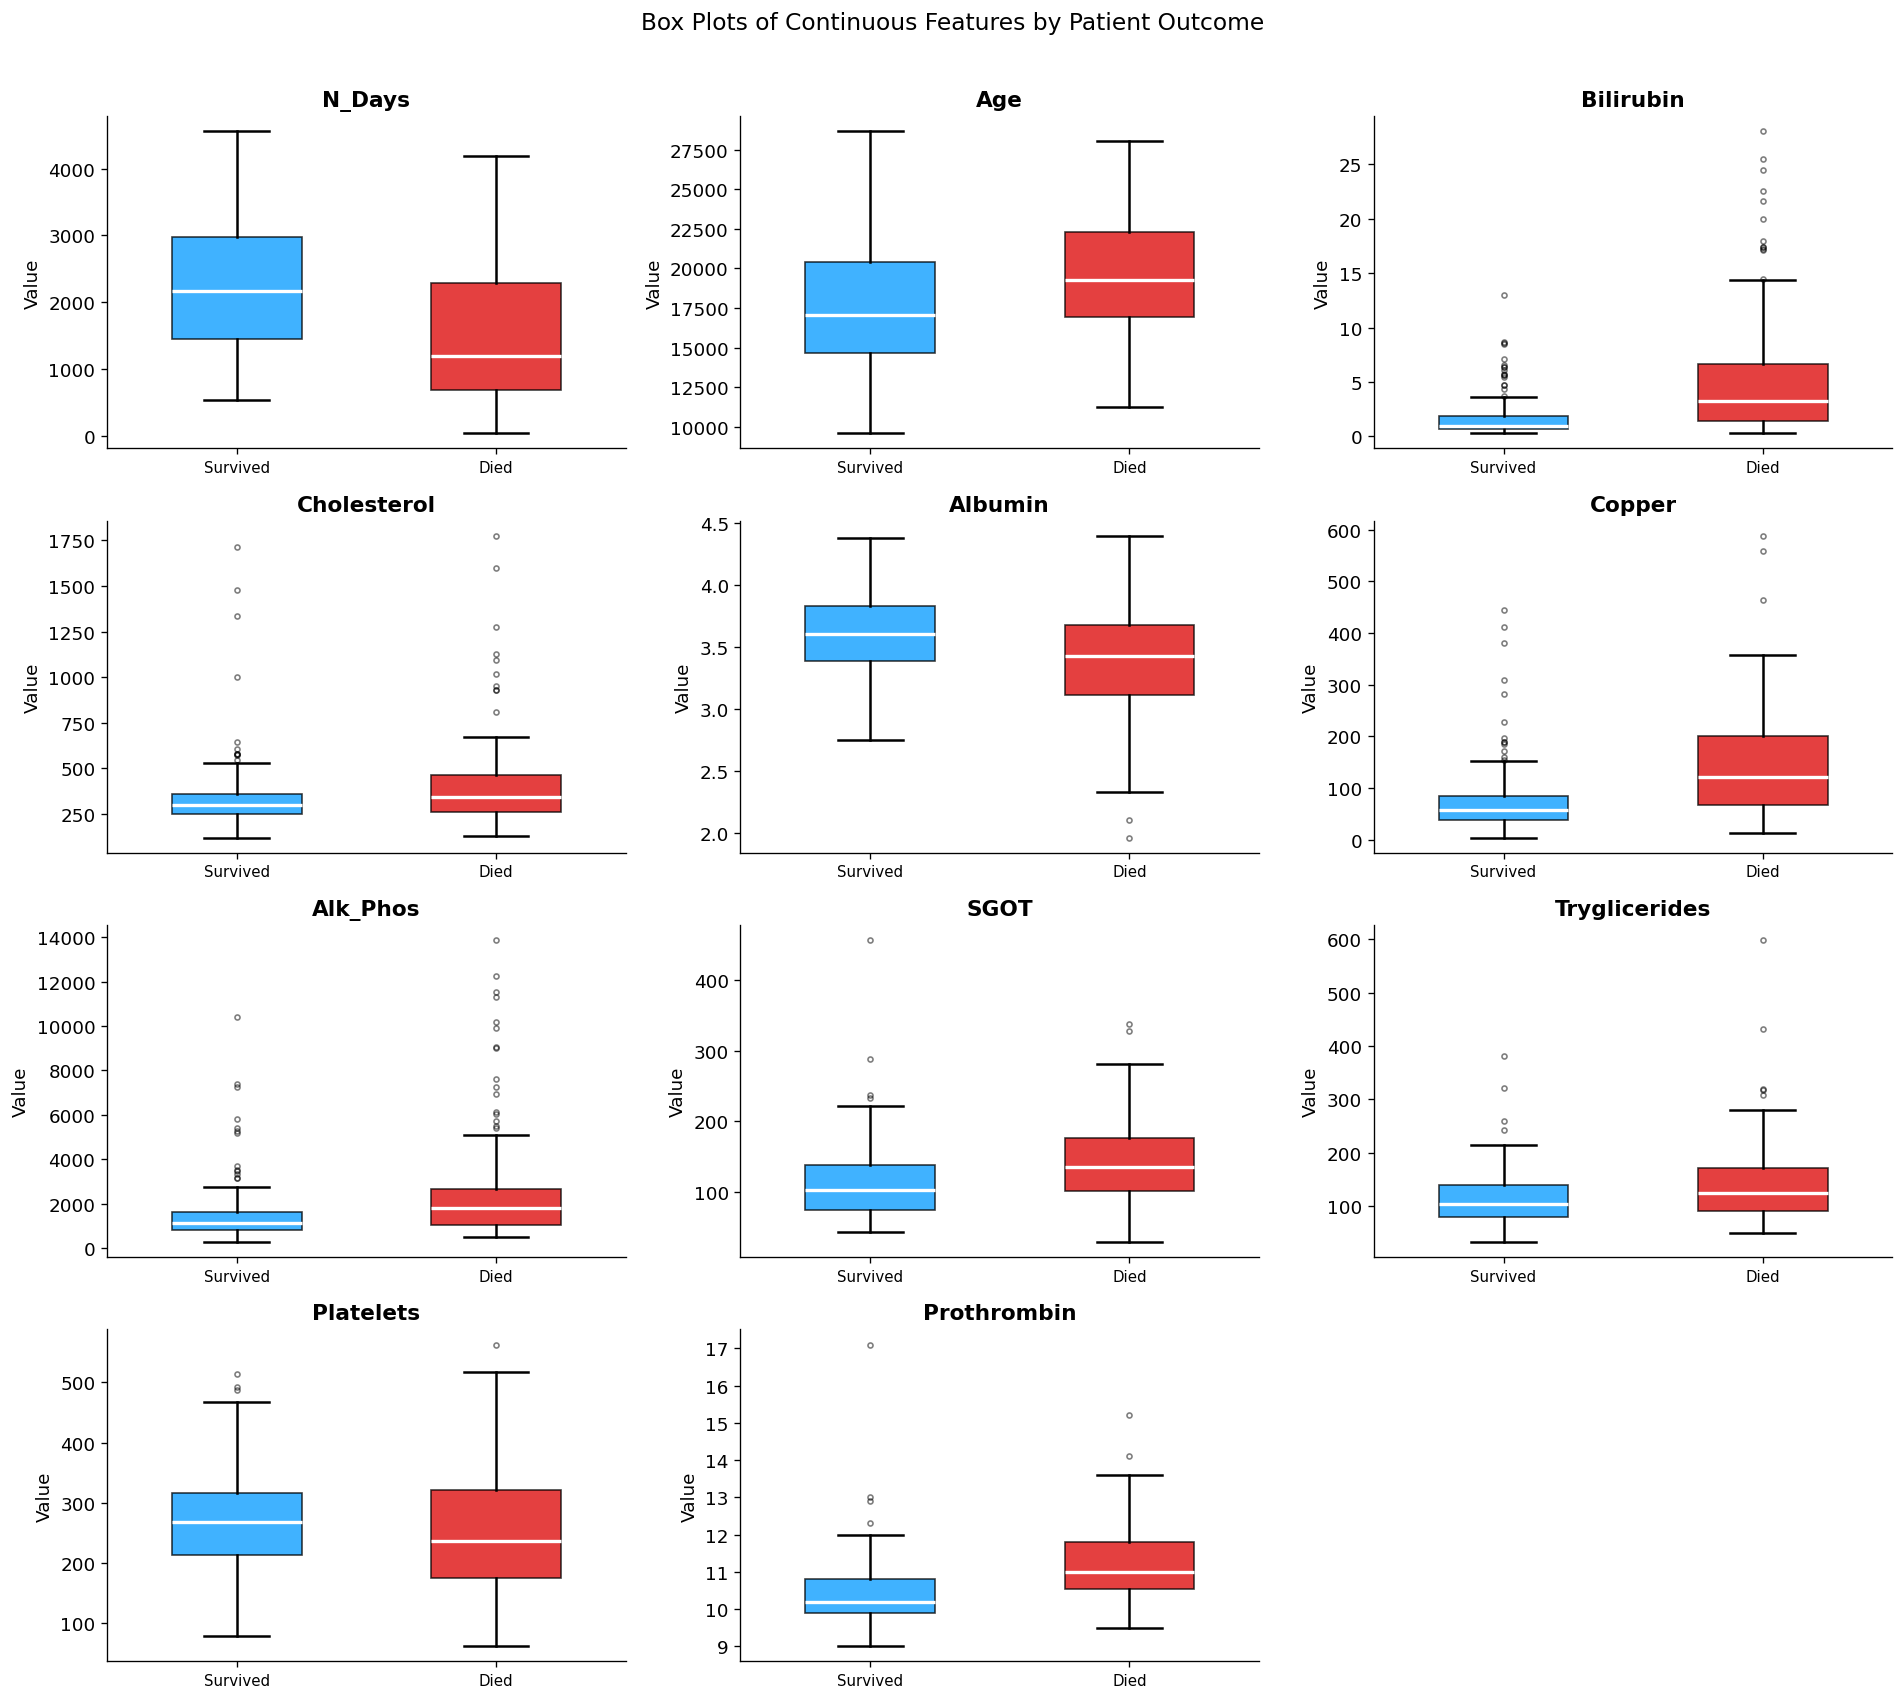

Figure saved.


In [8]:
n_cols = 3
n_rows = int(np.ceil(len(CONTINUOUS_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    ax = axes[i]

    data_by_group = [
        df_survived[col].dropna().values,
        df_deceased[col].dropna().values
    ]

    bp = ax.boxplot(
        data_by_group,
        patch_artist=True,
        widths=0.5,
        medianprops={'color': 'white', 'linewidth': 2},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5},
        whiskerprops={'linewidth': 1.5},
        capprops={'linewidth': 1.5},
    )

    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Survived', 'Died'], fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')

for j in range(len(CONTINUOUS_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots of Continuous Features by Patient Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output/figures/eda_boxplots.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 7: Violin Plots by Patient Outcome

Violin plots combine the information of a box plot with the full shape of the distribution. The width of the violin at any point represents how many patients have values near that level. This reveals multi-modal distributions and asymmetries that a box plot would hide — particularly useful for lab values like bilirubin and alkaline phosphatase which are known to be heavily right-skewed in liver disease.

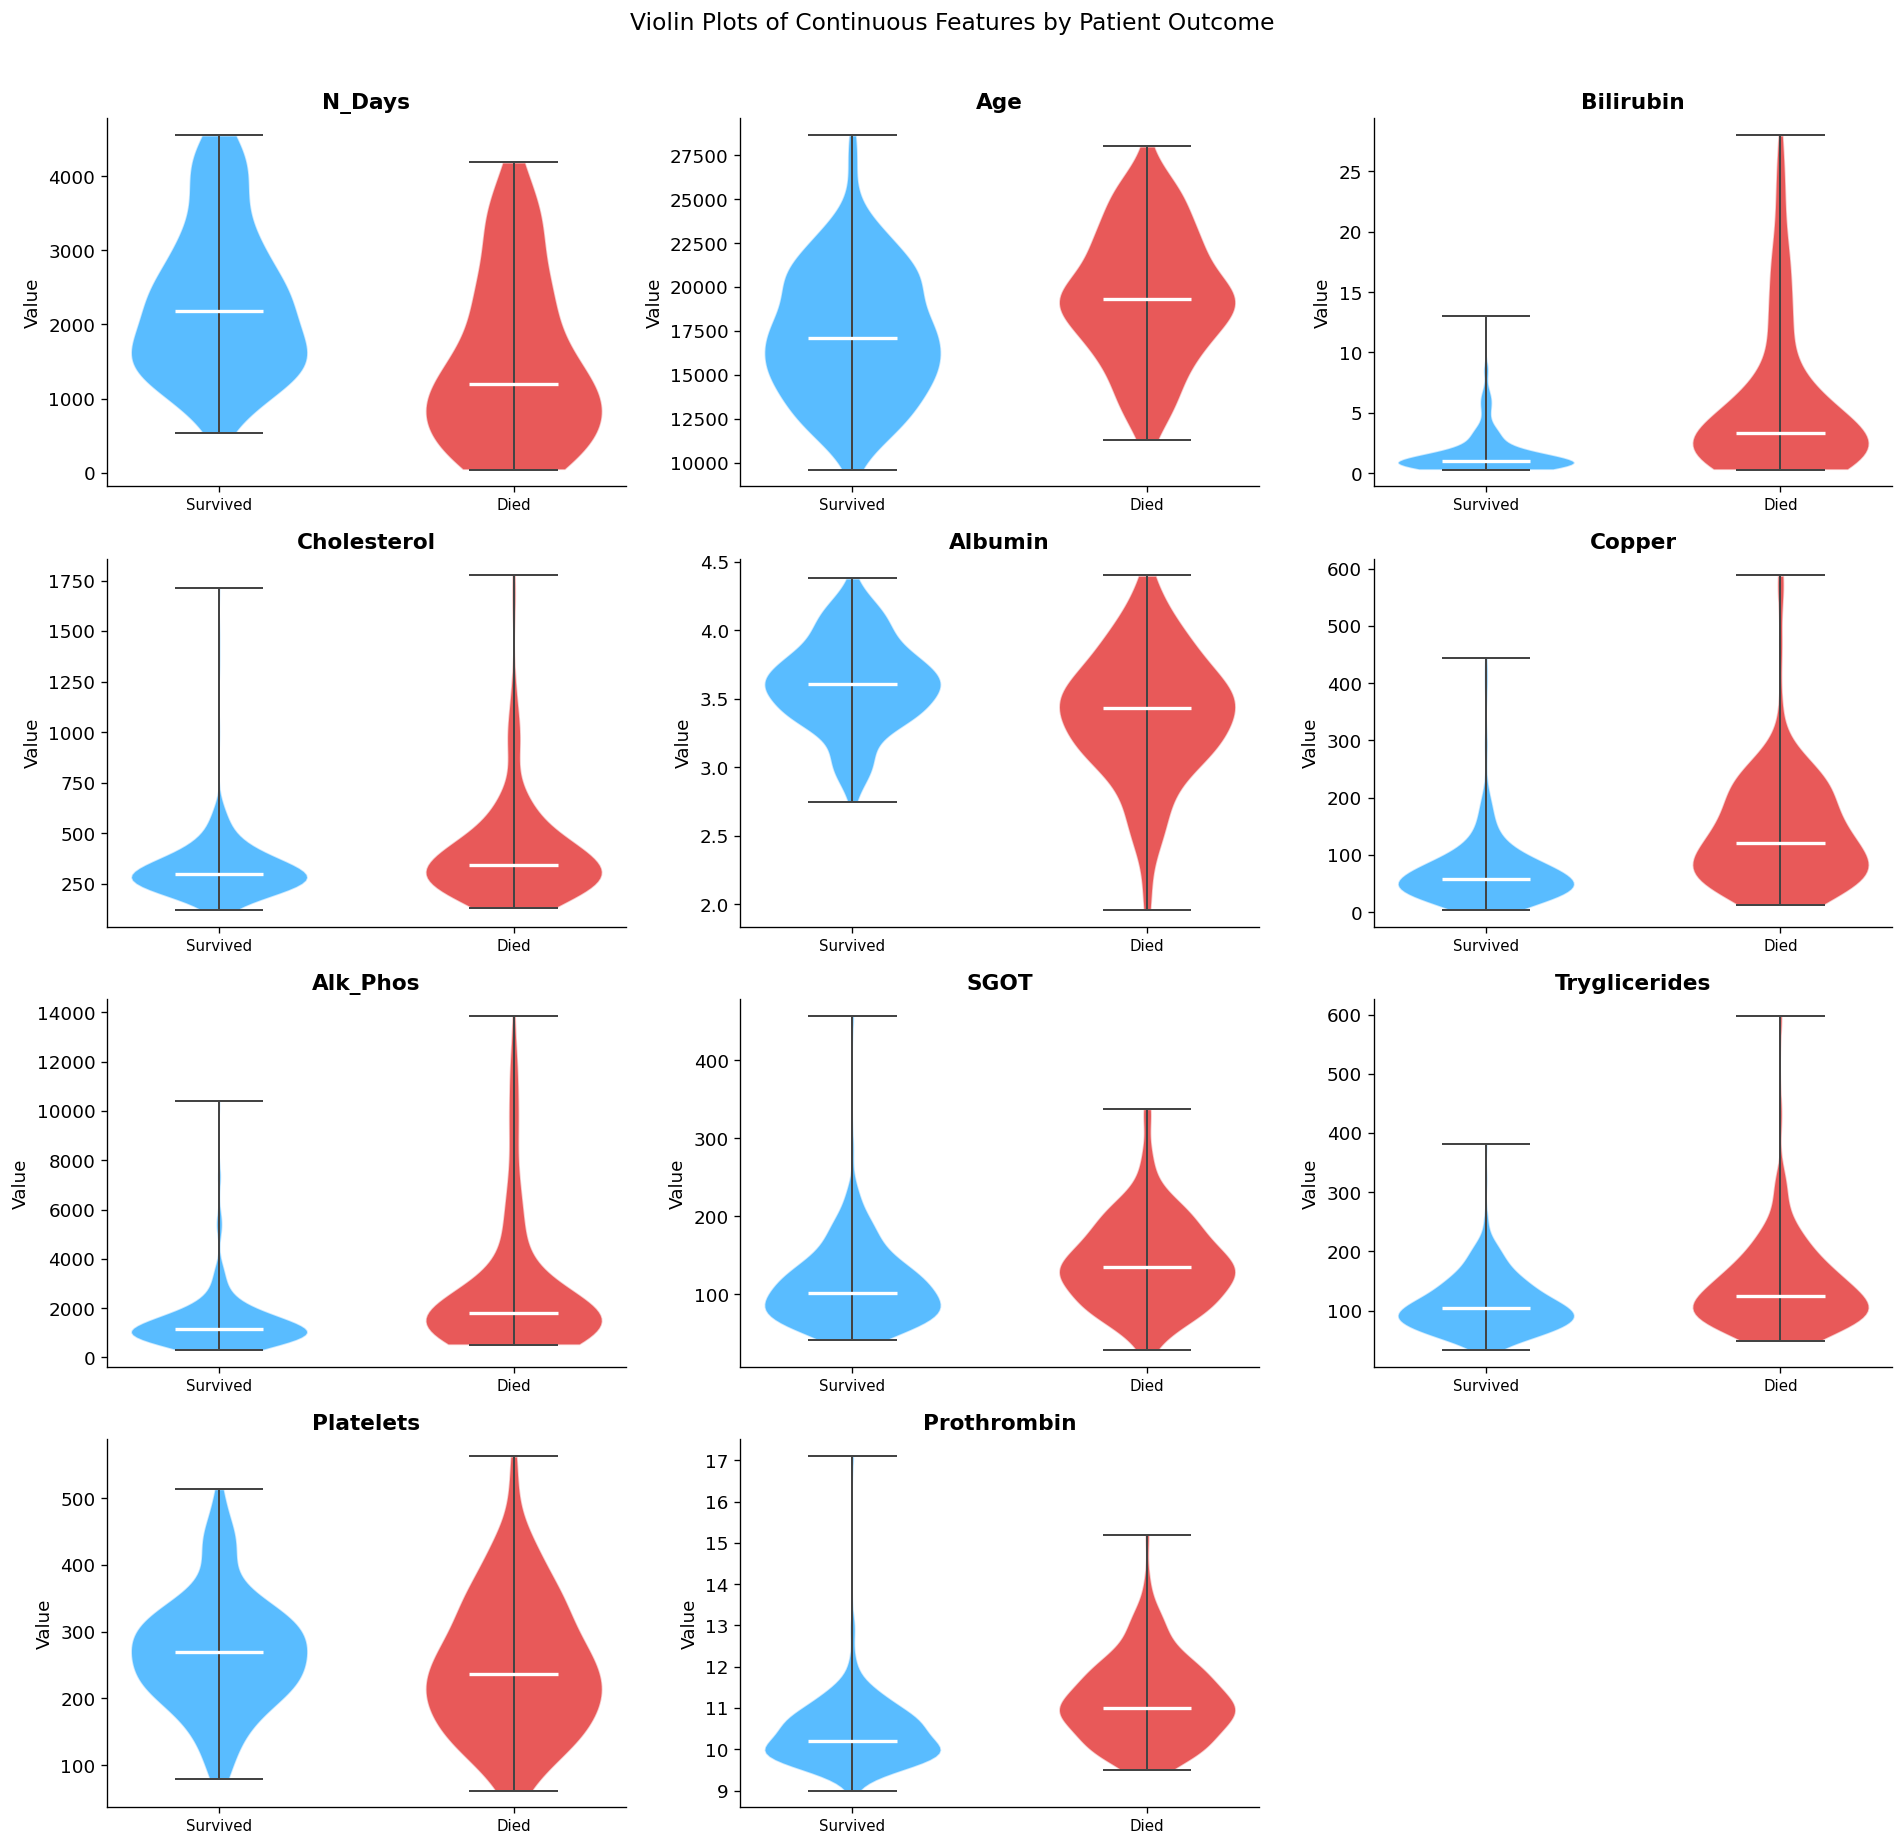

Figure saved.


In [9]:
n_cols = 3
n_rows = int(np.ceil(len(CONTINUOUS_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.8))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    ax = axes[i]

    data_by_group = [
        df_survived[col].dropna().values,
        df_deceased[col].dropna().values
    ]

    parts = ax.violinplot(
        data_by_group,
        positions=[1, 2],
        showmedians=True,
        showextrema=True,
        widths=0.6
    )

    for pc, color in zip(parts['bodies'], PALETTE):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
        pc.set_edgecolor('white')

    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    for part_name in ['cbars', 'cmaxes', 'cmins']:
        parts[part_name].set_color('#444444')
        parts[part_name].set_linewidth(1.2)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Survived', 'Died'], fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')

for j in range(len(CONTINUOUS_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Violin Plots of Continuous Features by Patient Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output/figures/eda_violin_plots.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 8: Correlation Matrix

The correlation matrix shows the pairwise Pearson correlation between all continuous features. Values near 1 or near -1 indicate strong linear relationships. Understanding correlations is important for two reasons: correlated features provide redundant information to classifiers, and the generative models should reproduce these correlation structures in the synthetic data.

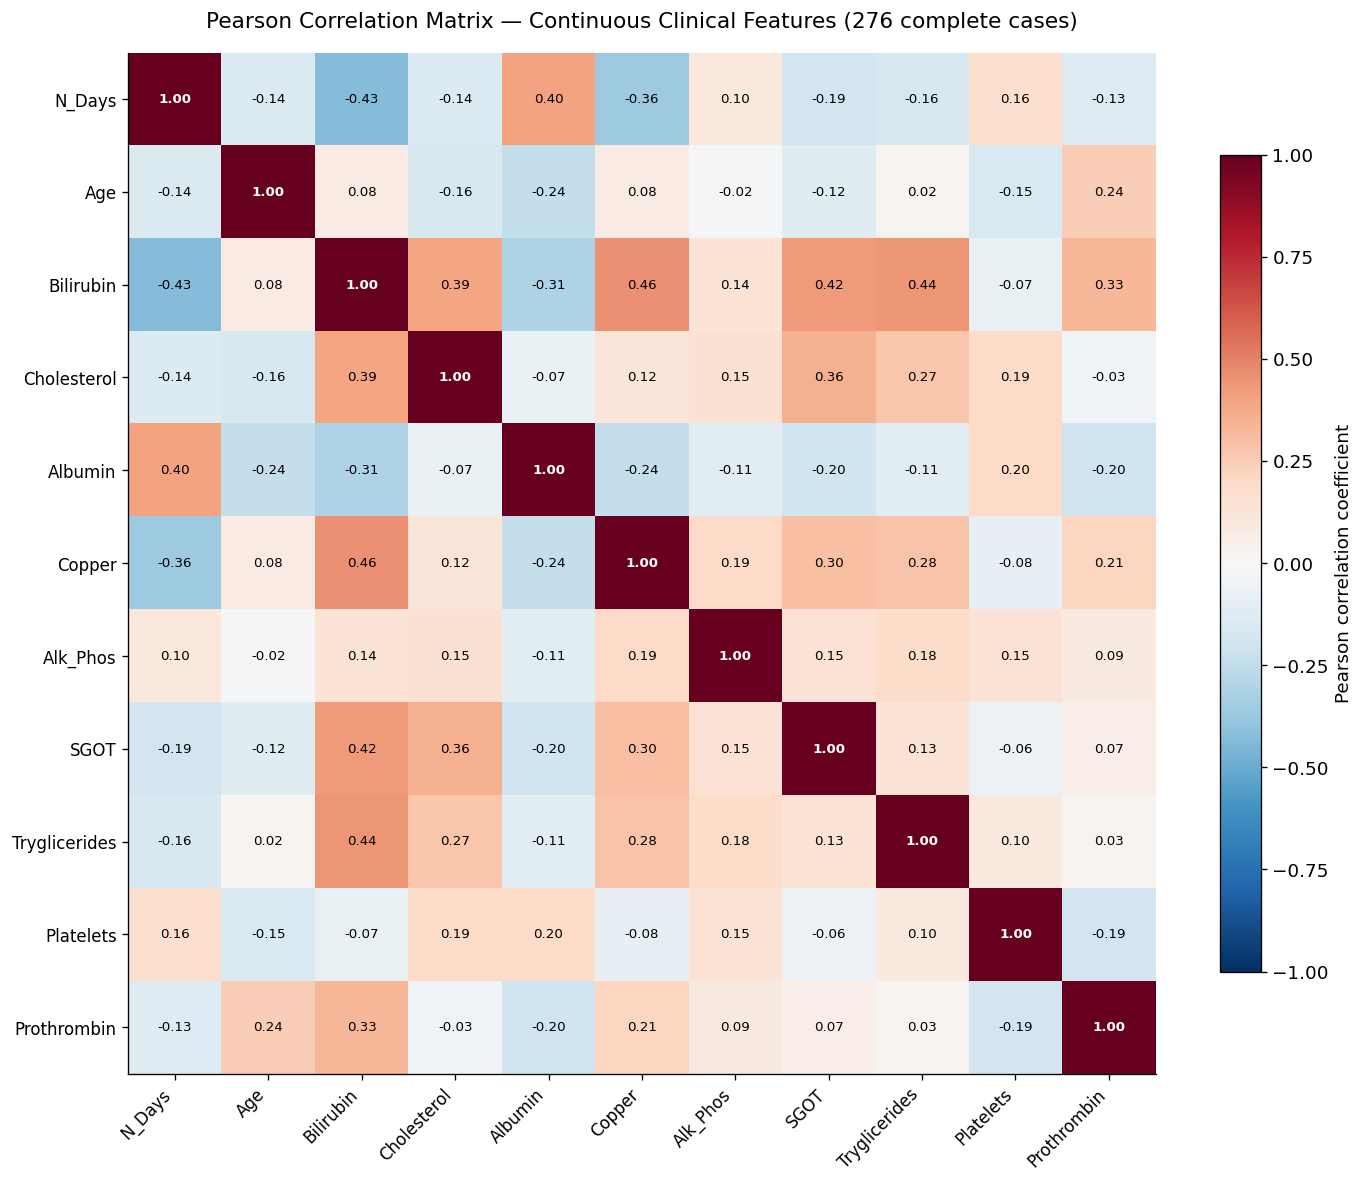

Figure saved.


In [10]:
corr = df[CONTINUOUS_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap manually so we control every aspect of its appearance
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation coefficient')

ax.set_xticks(range(len(CONTINUOUS_COLS)))
ax.set_yticks(range(len(CONTINUOUS_COLS)))
ax.set_xticklabels(CONTINUOUS_COLS, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(CONTINUOUS_COLS, fontsize=10)

# Annotate each cell with the correlation value
for row in range(len(CONTINUOUS_COLS)):
    for col in range(len(CONTINUOUS_COLS)):
        val = corr.values[row, col]
        text_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold' if abs(val) > 0.5 else 'normal')

ax.set_title('Pearson Correlation Matrix — Continuous Clinical Features (276 complete cases)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('output/figures/eda_correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [11]:
# Print the strongest correlations as a ranked list for easy reference
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'Correlation']
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs_Correlation', ascending=False)

print('Top 10 strongest pairwise correlations among continuous features:')
corr_pairs[['Feature A', 'Feature B', 'Correlation']].head(10).round(3)

Top 10 strongest pairwise correlations among continuous features:


,Feature A,Feature B,Correlation
21,Bilirubin,Copper,0.461
24,Bilirubin,Tryglicerides,0.440
1,N_Days,Bilirubin,-0.430
23,Bilirubin,SGOT,0.425
3,N_Days,Albumin,0.402
19,Bilirubin,Cholesterol,0.395
4,N_Days,Copper,-0.361
30,Cholesterol,SGOT,0.357
26,Bilirubin,Prothrombin,0.331
20,Bilirubin,Albumin,-0.312


---

## Section 9: Categorical Feature Distributions by Outcome

For each binary and ordinal feature, we compare how the categories are distributed between patients who deceased and those who survived. A feature where the proportions differ markedly between the two groups is clinically informative and should be captured accurately by the generative models.

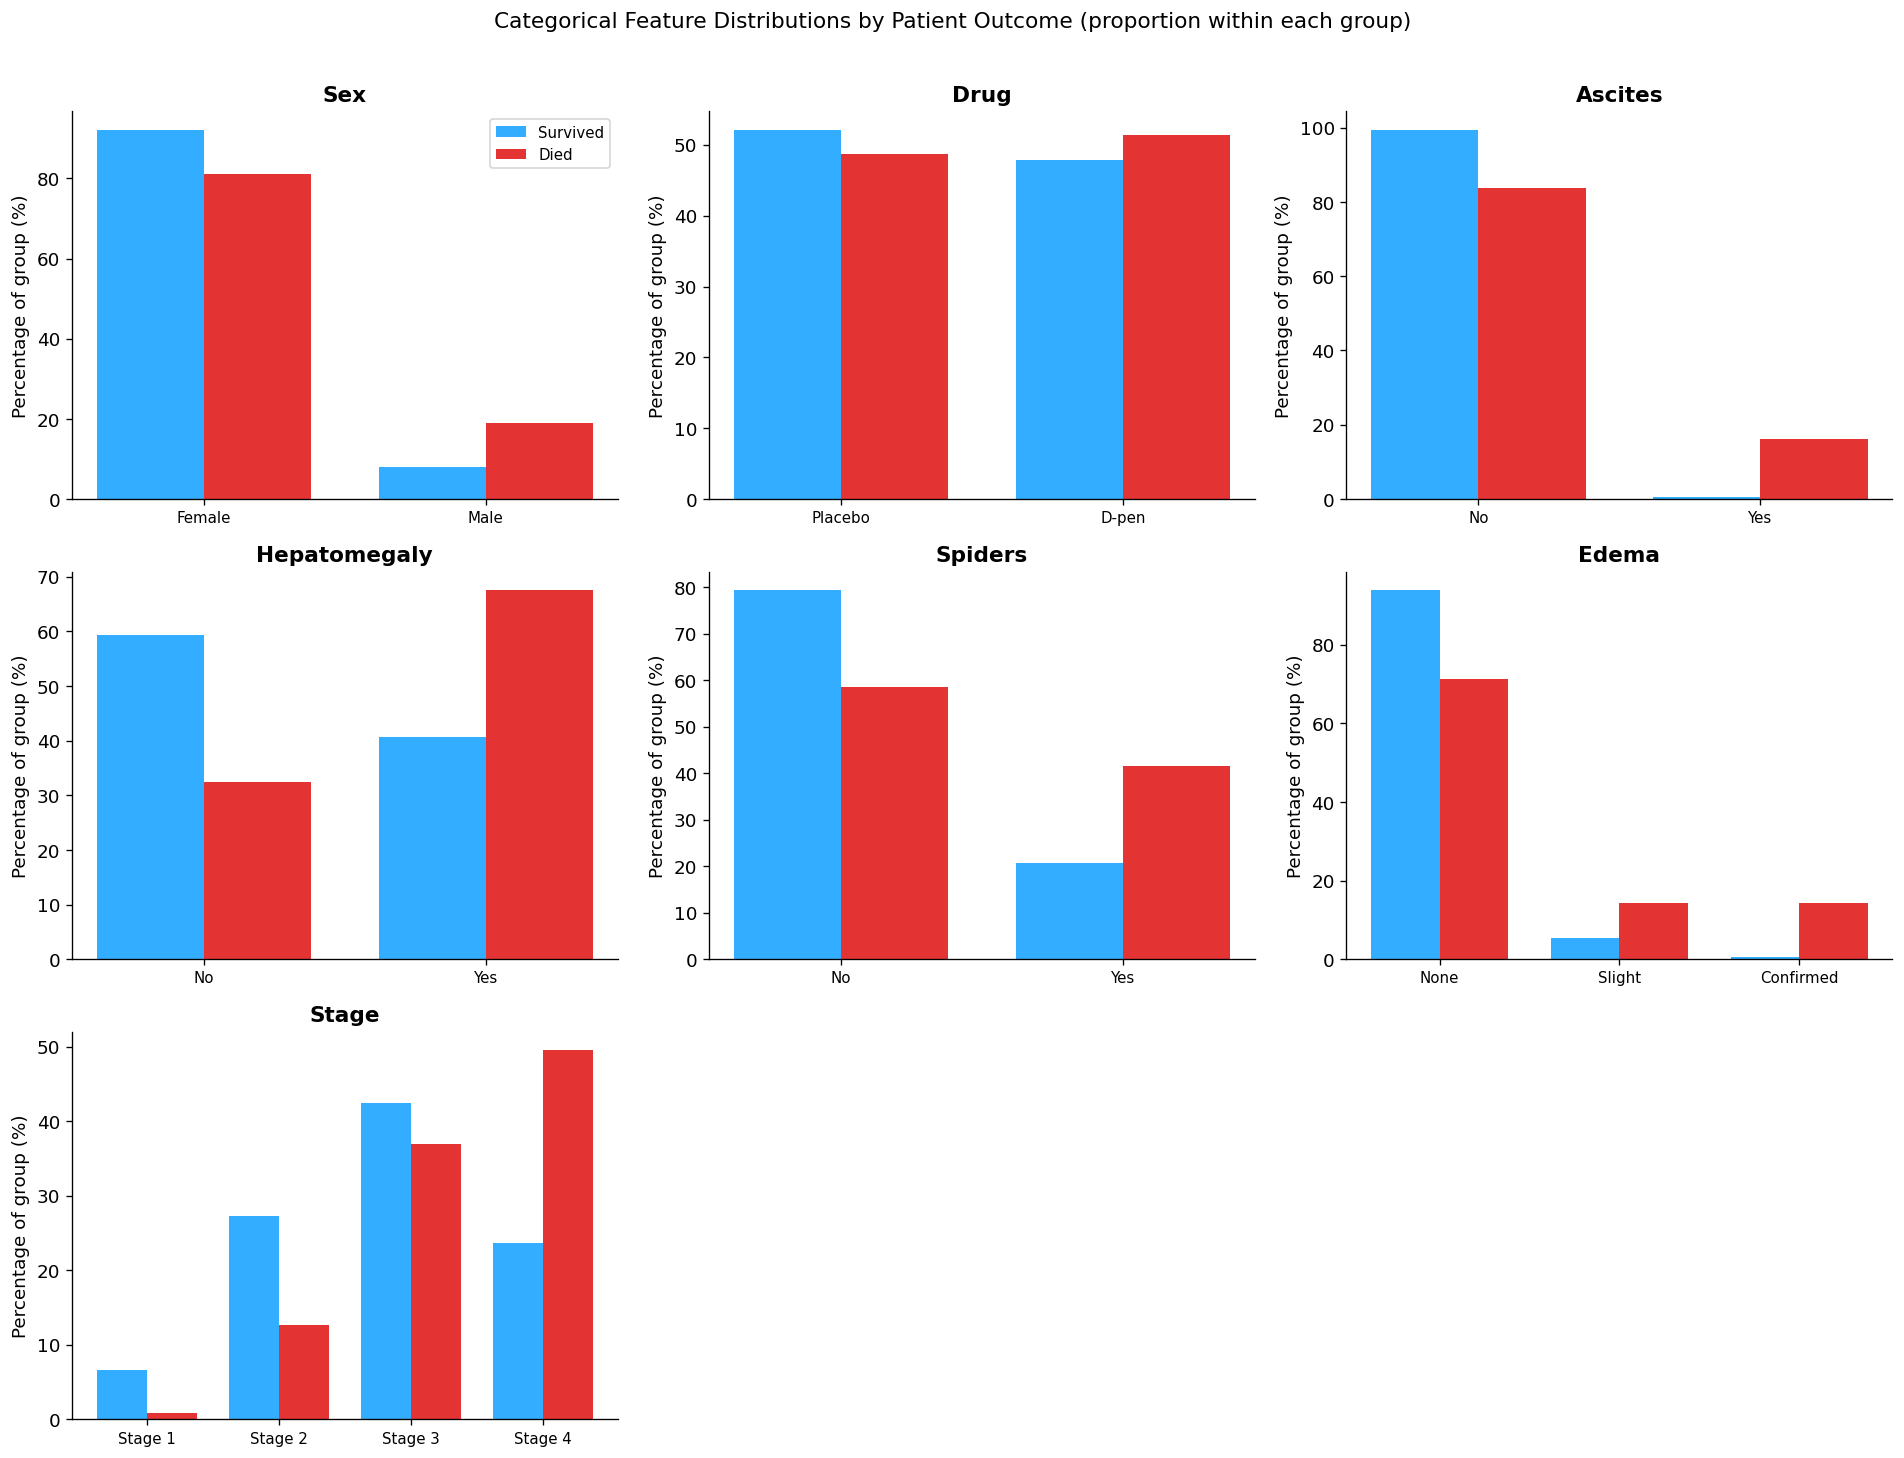

Figure saved.


In [12]:
CAT_LABELS = {
    'Sex':         {0: 'Female', 1: 'Male'},
    'Drug':        {0: 'Placebo', 1: 'D-pen'},
    'Ascites':     {0: 'No', 1: 'Yes'},
    'Hepatomegaly':{0: 'No', 1: 'Yes'},
    'Spiders':     {0: 'No', 1: 'Yes'},
    'Edema':       {0: 'None', 1: 'Slight', 2: 'Confirmed'},
    'Stage':       {1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3', 4: 'Stage 4'},
}

cat_cols = list(CAT_LABELS.keys())
n_cols   = 3
n_rows   = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    label_map = CAT_LABELS[col]
    categories = sorted(label_map.keys())
    x = np.arange(len(categories))
    width = 0.38

    surv_counts = df_survived[col].value_counts()
    deceased_counts = df_deceased[col].value_counts()

    surv_vals = [surv_counts.get(c, 0) for c in categories]
    deceased_vals = [deceased_counts.get(c, 0) for c in categories]

    # Normalise to proportions so groups of different sizes are comparable
    surv_pct = [v / len(df_survived) * 100 for v in surv_vals]
    deceased_pct = [v / len(df_deceased)     * 100 for v in deceased_vals]

    ax.bar(x - width/2, surv_pct, width, label='Survived', color=COLOR_SURVIVED, alpha=0.8)
    ax.bar(x + width/2, deceased_pct, width, label='Died',     color=COLOR_DIED,     alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([label_map[c] for c in categories], fontsize=9)
    ax.set_ylabel('Percentage of group (%)')
    ax.set_title(col, fontweight='bold')
    if i == 0:
        ax.legend(fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions by Patient Outcome (proportion within each group)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/figures/eda_categorical_distributions.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 10: Pairplot of Key Clinical Features

A pairplot shows the relationship between every pair of selected features simultaneously. Diagonal panels show each feature's distribution. Off-diagonal panels show scatter plots coloured by outcome. This is useful for identifying non-linear relationships and clusters that might inform the generative model design.

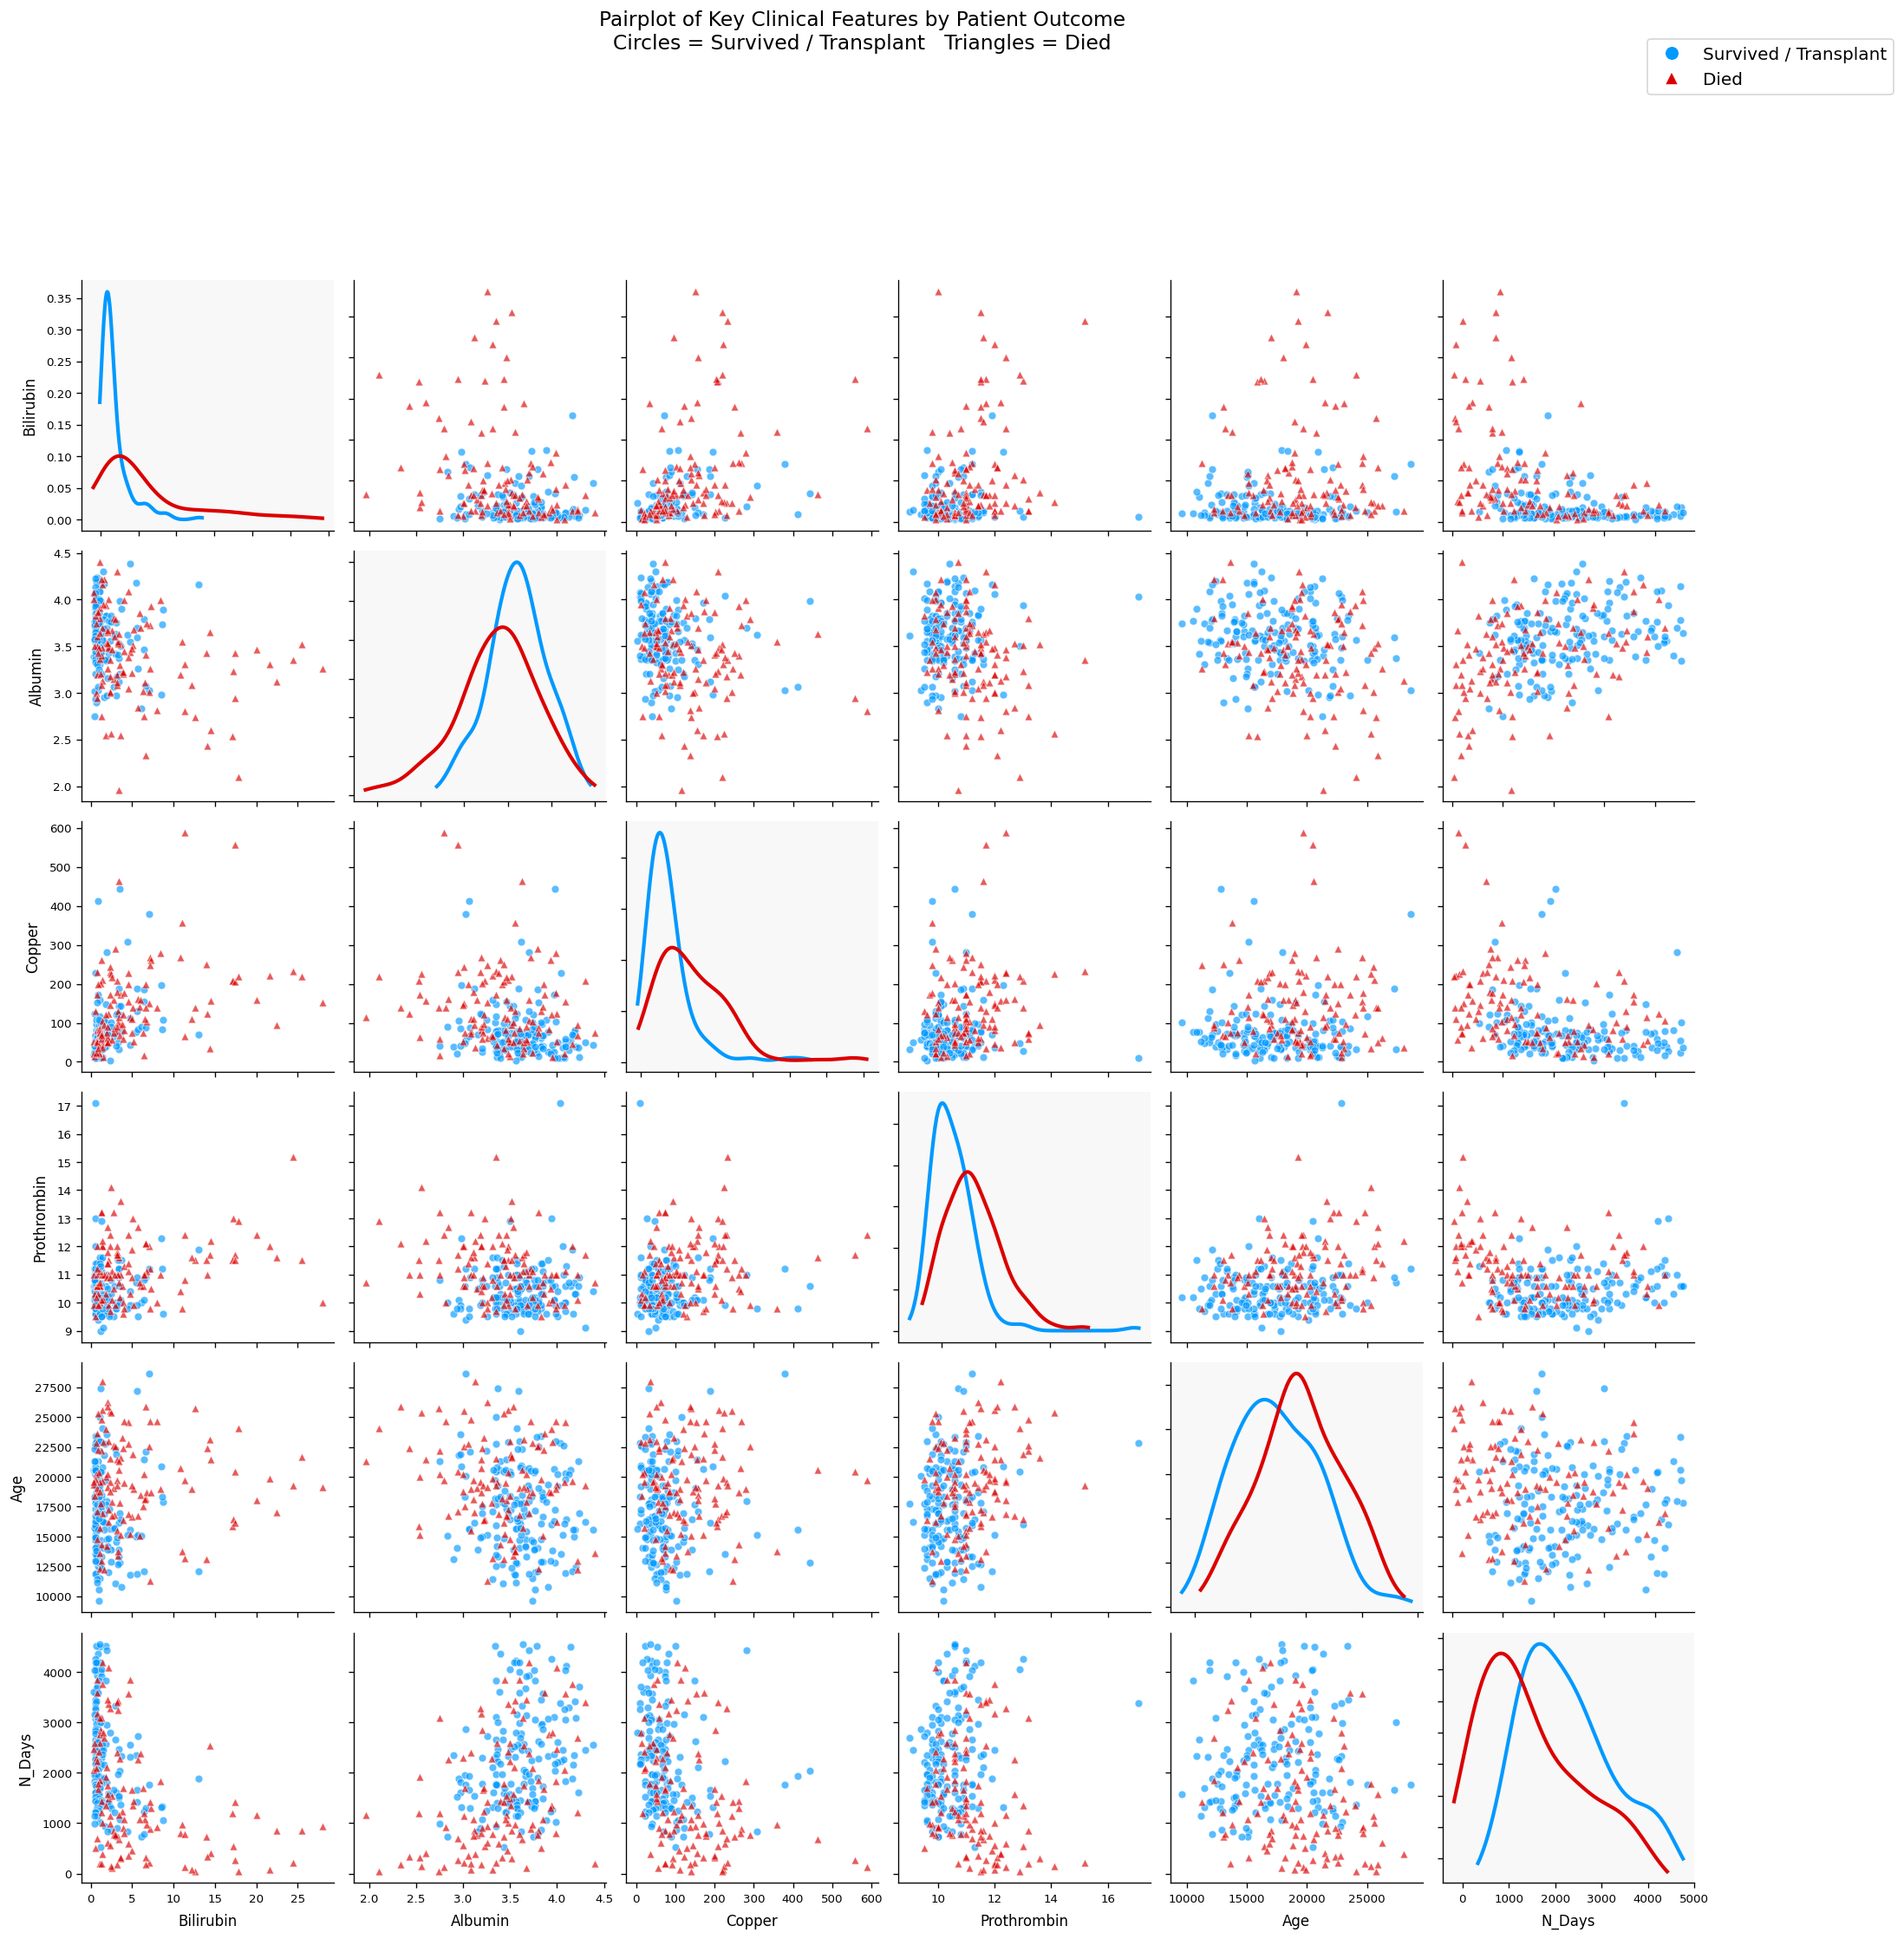

Figure saved.


In [13]:
# Key features selected for the pairplot.
# A full 11x11 grid would be unreadable — six clinically important features
# give enough cross-feature context without overcrowding.
KEY_FEATURES = ['Bilirubin', 'Albumin', 'Copper', 'Prothrombin', 'Age', 'N_Days']

n = len(KEY_FEATURES)

# A larger canvas gives each subplot enough room so that
# individual data points do not sit on top of each other.
fig, axes = plt.subplots(n, n, figsize=(20, 20))
fig.subplots_adjust(hspace=0.08, wspace=0.08)

# Visual properties for each outcome group.
# Using different marker shapes (circle vs triangle) in addition to colour
# means the groups remain distinguishable even in greyscale printouts.
GROUPS = [
    dict(df=df_survived, color='#0099FF', marker='o',
         label='Survived / Transplant', zorder=2),
    dict(df=df_deceased,     color='#DC0000', marker='^',
         label='Died',                   zorder=3),
]

for row_idx, feat_y in enumerate(KEY_FEATURES):
    for col_idx, feat_x in enumerate(KEY_FEATURES):
        ax = axes[row_idx][col_idx]

        if row_idx == col_idx:
            # Diagonal — KDE only, no fill, so the curves are crisp and clean
            for g in GROUPS:
                vals = g['df'][feat_x].dropna()
                kde_x = np.linspace(vals.min() - vals.std()*0.2,
                                    vals.max() + vals.std()*0.2, 300)
                try:
                    kde = stats.gaussian_kde(vals, bw_method=0.4)
                    ax.plot(kde_x, kde(kde_x),
                            color=g['color'], linewidth=2.5, label=g['label'])
                except Exception:
                    pass
            ax.set_facecolor('#F8F8F8')

        else:
            # Off-diagonal — scatter plot.
            # White edge on each marker lifts overlapping points apart visually.
            # Moderate alpha keeps dense regions readable without hiding structure.
            for g in GROUPS:
                ax.scatter(
                    g['df'][feat_x], g['df'][feat_y],
                    color=g['color'],
                    marker=g['marker'],
                    s=28,               # larger than default so points are clearly visible
                    alpha=0.65,
                    edgecolors='white', # white border separates touching dots
                    linewidths=0.5,
                    zorder=g['zorder'],
                )

        # Axis labels only on the outer edges to avoid repetition
        if row_idx == n - 1:
            ax.set_xlabel(feat_x, fontsize=10, labelpad=6)
        else:
            ax.set_xticklabels([])

        if col_idx == 0:
            ax.set_ylabel(feat_y, fontsize=10, labelpad=6)
        else:
            ax.set_yticklabels([])

        ax.tick_params(labelsize=8)

# Single legend placed outside the grid in the upper-right corner
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0099FF',
           markersize=10, label='Survived / Transplant'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#DC0000',
           markersize=10, label='Died'),
]
fig.legend(handles=legend_elements, loc='upper right',
           fontsize=12, bbox_to_anchor=(1.0, 1.0),
           frameon=True, edgecolor='#cccccc')

plt.suptitle(
    'Pairplot of Key Clinical Features by Patient Outcome\n'
    'Circles = Survived / Transplant   Triangles = Died',
    fontsize=14, y=1.01
)
plt.savefig('output/figures/eda_pairplot.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 11: Outlier Profile Using the IQR Method

The IQR method defines outliers as values below Q1 minus 1.5 times the IQR or above Q3 plus 1.5 times the IQR. We apply this to the real data to understand how many genuine extreme values exist per feature. This matters because the synthetic data will be filtered using the same criterion — knowing how many real outliers there are tells us whether the IQR filter is calibrated appropriately.

In [14]:
outlier_rows = []
for col in CONTINUOUS_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_rows.append({
        'Feature':    col,
        'Q1':         round(q1, 2),
        'Q3':         round(q3, 2),
        'IQR':        round(iqr, 2),
        'Lower fence':round(lo, 2),
        'Upper fence':round(hi, 2),
        'Outliers (n)': n_out,
        'Outlier (%)':  round(n_out / len(df) * 100, 1),
    })

outlier_df = pd.DataFrame(outlier_rows)
print('IQR outlier profile for the real complete-case data:')
outlier_df

IQR outlier profile for the real complete-case data:


,Feature,Q1,Q3,IQR,Lower fence,Upper fence,Outliers (n),Outlier (%)
0,N_Days,1185.75,2689.75,1504.00,-1070.25,4945.75,0,0.0
1,Age,15162.50,20667.50,5505.00,6905.00,28925.00,0,0.0
2,Bilirubin,0.80,3.52,2.72,-3.29,7.61,27,9.8
3,Cholesterol,249.50,401.00,151.50,22.25,628.25,20,7.2
4,Albumin,3.31,3.77,0.46,2.62,4.47,9,3.3
5,Copper,42.75,129.25,86.50,-87.00,259.00,15,5.4
6,Alk_Phos,922.50,2068.25,1145.75,-796.12,3786.88,28,10.1
7,SGOT,82.46,153.45,70.99,-24.03,259.94,6,2.2
8,Tryglicerides,85.00,151.25,66.25,-14.38,250.62,10,3.6
9,Platelets,200.00,318.25,118.25,22.62,495.62,3,1.1


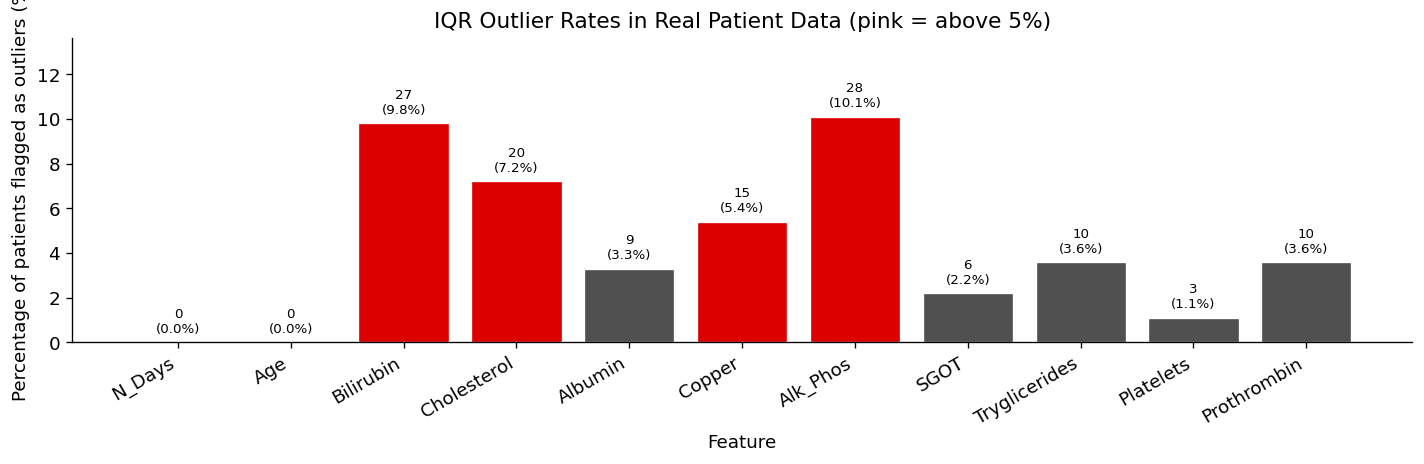

Figure saved.


In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = [COLOR_DIED if v > 5 else COLOR_ALL for v in outlier_df['Outlier (%)']]
bars = ax.bar(outlier_df['Feature'], outlier_df['Outlier (%)'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar, row in zip(bars, outlier_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row._7}\n({row._8}%)', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Feature')
ax.set_ylabel('Percentage of patients flagged as outliers (%)')
ax.set_title('IQR Outlier Rates in Real Patient Data (pink = above 5%)')
ax.set_ylim(0, outlier_df['Outlier (%)'].max() * 1.35)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/figures/eda_outlier_profile.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 12: Normality Testing — Shapiro-Wilk

We formally test whether each continuous feature follows a normal distribution. This directly informs the choice of statistical tests used later in Notebook 3. Features that are not normally distributed require non-parametric tests such as the Kolmogorov-Smirnov test rather than t-tests.

In [16]:
normality_rows = []
for col in CONTINUOUS_COLS:
    w, p = stats.shapiro(df[col].dropna())
    normality_rows.append({
        'Feature':    col,
        'W statistic':round(w, 4),
        'p value':    round(p, 6),
        'Normal (p>0.05)': 'Yes' if p > 0.05 else 'No',
    })

norm_df = pd.DataFrame(normality_rows)
print('Shapiro-Wilk normality test results:')
print(f'  {(norm_df["Normal (p>0.05)"] == "Yes").sum()} of {len(norm_df)} features are normally distributed')
print()
norm_df

Shapiro-Wilk normality test results:
  1 of 11 features are normally distributed



,Feature,W statistic,p value,Normal (p>0.05)
0,N_Days,0.9707,0.000020,No
1,Age,0.9907,0.076851,Yes
2,Bilirubin,0.6252,0.000000,No
3,Cholesterol,0.6478,0.000000,No
4,Albumin,0.9785,0.000356,No
5,Copper,0.7883,0.000000,No
6,Alk_Phos,0.6211,0.000000,No
7,SGOT,0.9107,0.000000,No
8,Tryglicerides,0.8139,0.000000,No
9,Platelets,0.9886,0.028048,No


---

## Section 13: Summary of EDA Findings

This section collects the key insights from the exploratory analysis into a concise narrative suitable for use in the paper's dataset description section.

In [17]:
normal_features    = norm_df[norm_df['Normal (p>0.05)'] == 'Yes']['Feature'].tolist()
nonnormal_features = norm_df[norm_df['Normal (p>0.05)'] == 'No']['Feature'].tolist()
high_outlier_feats = outlier_df[outlier_df['Outlier (%)'] > 5]['Feature'].tolist()

top_corr = corr_pairs.head(3)

print('EDA Summary')
print('=' * 60)
print(f'Total raw patients:          418')
print(f'Complete case patients:      276')
print(f'Patients who deceased:           {len(df_deceased)} ({len(df_deceased)/len(df)*100:.1f}%)')
print(f'Patients who survived:       {len(df_survived)} ({len(df_survived)/len(df)*100:.1f}%)')
print()
print(f'Features with normal dist:   {normal_features}')
print(f'Features NOT normal:         {nonnormal_features}')
print()
print(f'Features with >5% outliers:  {high_outlier_feats}')
print()
print('Strongest feature correlations:')
for _, row in top_corr.iterrows():
    print(f'  {row["Feature A"]} — {row["Feature B"]}: r = {row["Correlation"]:.3f}')
print()
print('All EDA figures saved to output/figures/')
print('This notebook is complete. Proceed to Notebook 01.')

EDA Summary
Total raw patients:          418
Complete case patients:      276
Patients who deceased:           111 (40.2%)
Patients who survived:       165 (59.8%)

Features with normal dist:   ['Age']
Features NOT normal:         ['N_Days', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

Features with >5% outliers:  ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos']

Strongest feature correlations:
  Bilirubin — Copper: r = 0.461
  Bilirubin — Tryglicerides: r = 0.440
  N_Days — Bilirubin: r = -0.430

All EDA figures saved to output/figures/
This notebook is complete. Proceed to Notebook 01.


---

## Section 14: 3D Clinical Biomarker Space

Three of the most clinically informative continuous features — Bilirubin (liver function), Albumin (nutritional and liver synthetic status), and Prothrombin time (blood clotting, a direct measure of liver function) — are plotted together in three dimensions. Each patient is a point coloured by outcome. Viewing the data from four different angles gives a complete picture of how the two outcome groups are distributed in this three-dimensional biomarker space and whether any regions are dominated by one outcome class.

These three biomarkers are among the key components of the Mayo Clinic PBC risk score, making their joint distribution directly relevant to the article's clinical framing.

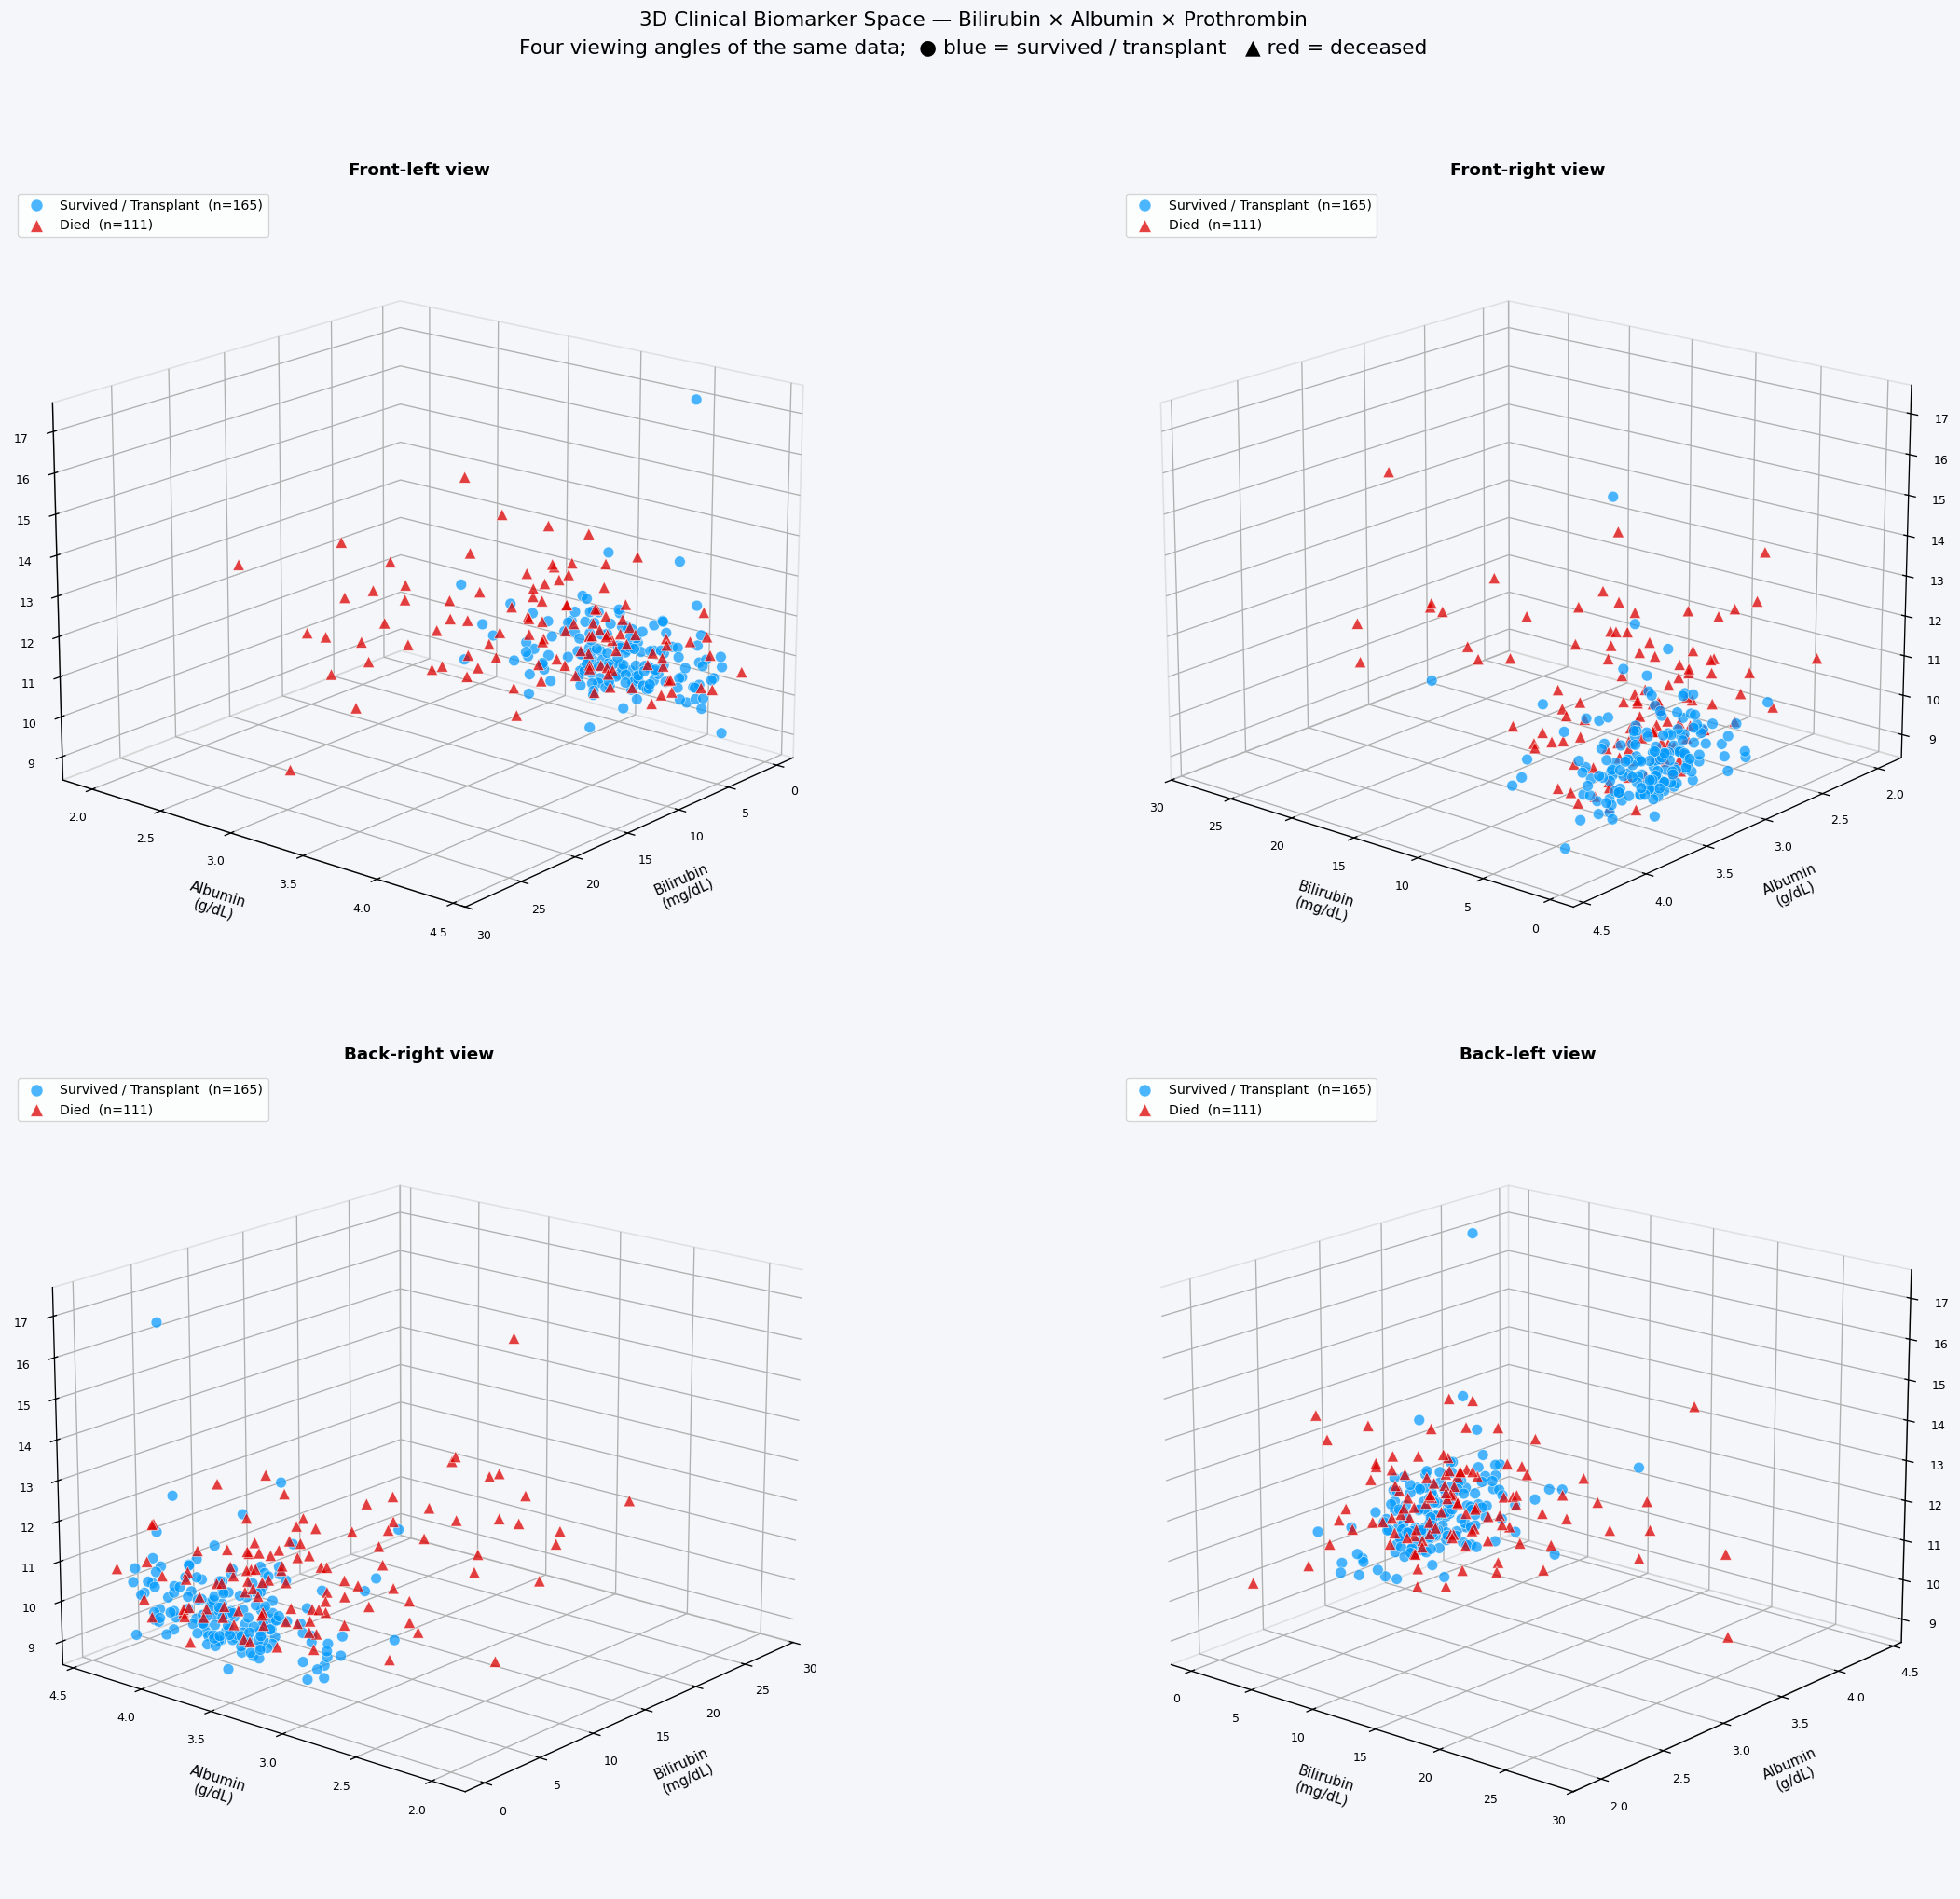

3D clinical biomarker space figure saved.


In [18]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

feat_x, feat_y, feat_z = 'Bilirubin', 'Albumin', 'Prothrombin'
df_3d = df[[feat_x, feat_y, feat_z, TARGET_COL]].dropna()
surv_3d = df_3d[df_3d[TARGET_COL] == 0]
deceased_3d = df_3d[df_3d[TARGET_COL] == 1]

VIEW_ANGLES = [(18, 40), (18, 130), (18, 220), (18, 310)]
TITLES      = ['Front-left view', 'Front-right view', 'Back-right view', 'Back-left view']

fig = plt.figure(figsize=(22, 17))
fig.patch.set_facecolor('#F4F6FA')

for idx, ((elev, azim), title) in enumerate(zip(VIEW_ANGLES, TITLES)):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    ax.set_facecolor('#F4F6FA')

    ax.scatter(surv_3d[feat_x], surv_3d[feat_y], surv_3d[feat_z],
               c=COLOR_SURVIVED, s=50, alpha=0.70,
               edgecolors='white', linewidths=0.4,
               label=f'Survived / Transplant  (n={len(surv_3d)})',
               depthshade=True, zorder=3)
    ax.scatter(deceased_3d[feat_x], deceased_3d[feat_y], deceased_3d[feat_z],
               c=COLOR_DIED, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.4,
               label=f'Died  (n={len(deceased_3d)})',
               marker='^', depthshade=True, zorder=4)

    ax.set_xlabel('Bilirubin\n(mg/dL)',  fontsize=9, labelpad=10)
    ax.set_ylabel('Albumin\n(g/dL)',     fontsize=9, labelpad=10)
    ax.set_zlabel('Prothrombin\n(sec)',  fontsize=9, labelpad=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.view_init(elev=elev, azim=azim)
    ax.tick_params(labelsize=7.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#CCCCCC')
    ax.yaxis.pane.set_edgecolor('#CCCCCC')
    ax.zaxis.pane.set_edgecolor('#CCCCCC')
    ax.grid(True, linestyle='--', linewidth=0.5, color='#DDDDDD')

    # Legend on every panel so each view is self-explanatory
    legend = ax.legend(fontsize=8.5, loc='upper left',
                       frameon=True, facecolor='white',
                       edgecolor='#CCCCCC', markerscale=1.1)
    legend.get_frame().set_linewidth(0.8)

plt.suptitle(
    '3D Clinical Biomarker Space — Bilirubin × Albumin × Prothrombin\n'
    'Four viewing angles of the same data;  ● blue = survived / transplant   ▲ red = deceased',
    fontsize=13, y=1.01, linespacing=1.6
)
plt.tight_layout(pad=2.5)
plt.savefig('output/figures/3d_clinical_biomarker_space.png', bbox_inches='tight')
plt.show()
print('3D clinical biomarker space figure saved.')

---

## Section 15: 3D PCA Projection of All Clinical Features

Principal Component Analysis (PCA) reduces the full 18-dimensional feature space to three orthogonal axes that capture the directions of maximum variance. Plotting patients in this 3D PCA space reveals whether the two outcome classes are linearly separable and shows where the two groups overlap most. Each axis label shows the percentage of total variance that component explains. Loading vectors for the five features that contribute most to the first two principal components are overlaid as arrows.

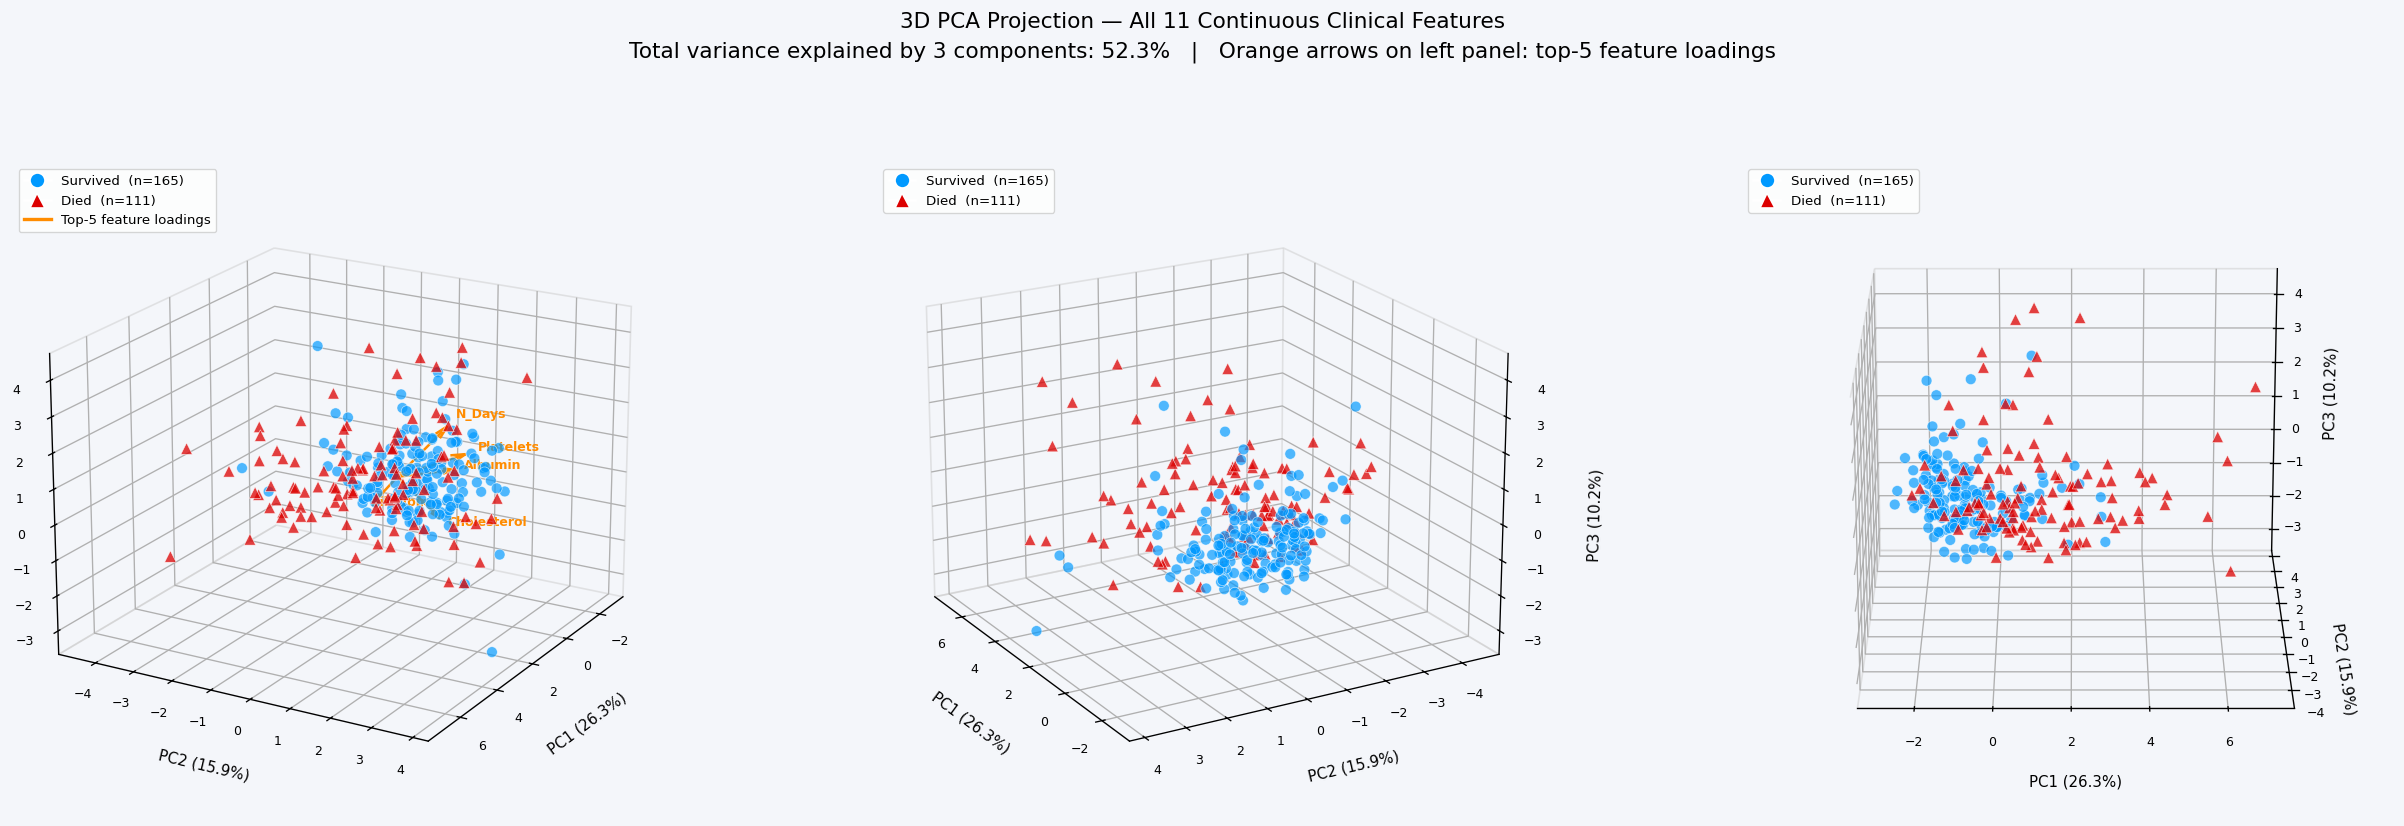

3D PCA projection figure saved.


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

pca_cols = [c for c in CONTINUOUS_COLS if c in df.columns]
df_pca   = df[pca_cols + [TARGET_COL]].dropna()

scaler_pca = StandardScaler()
X_pca_raw  = scaler_pca.fit_transform(df_pca[pca_cols])
y_pca      = df_pca[TARGET_COL].values

pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_pca_raw)

ev    = pca3.explained_variance_ratio_
total = ev.sum()

loadings = pca3.components_
top5_idx = np.argsort(np.abs(loadings[0]) + np.abs(loadings[1]))[-5:]

VIEW_ANGLES_PCA = [(20, 30), (20, 150), (20, 270)]
surv_m = y_pca == 0
deceased_m = y_pca == 1

fig = plt.figure(figsize=(22, 7))
fig.patch.set_facecolor('#F4F6FA')

for idx, (elev, azim) in enumerate(VIEW_ANGLES_PCA):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.set_facecolor('#F4F6FA')

    ax.scatter(X_3d[surv_m, 0], X_3d[surv_m, 1], X_3d[surv_m, 2],
               c=COLOR_SURVIVED, s=42, alpha=0.68,
               edgecolors='white', linewidths=0.4,
               label=f'Survived  (n={surv_m.sum()})', depthshade=True)
    ax.scatter(X_3d[deceased_m, 0], X_3d[deceased_m, 1], X_3d[deceased_m, 2],
               c=COLOR_DIED, s=48, alpha=0.75,
               edgecolors='white', linewidths=0.4,
               label=f'Died  (n={deceased_m.sum()})',
               marker='^', depthshade=True)

    if idx == 0:
        scale = X_3d[:, :3].std() * 2.5
        for fi in top5_idx:
            ax.quiver(0, 0, 0,
                      loadings[0, fi] * scale,
                      loadings[1, fi] * scale,
                      loadings[2, fi] * scale,
                      color='#FF8C00', linewidth=1.5, arrow_length_ratio=0.2)
            ax.text(loadings[0, fi] * scale * 1.18,
                    loadings[1, fi] * scale * 1.18,
                    loadings[2, fi] * scale * 1.18,
                    pca_cols[fi], fontsize=7.5, color='#FF8C00', fontweight='bold')

    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=9, labelpad=10)
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=9, labelpad=10)
    ax.set_zlabel(f'PC3 ({ev[2]*100:.1f}%)', fontsize=9, labelpad=10)
    ax.view_init(elev=elev, azim=azim)
    ax.tick_params(labelsize=7.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#CCCCCC')
    ax.yaxis.pane.set_edgecolor('#CCCCCC')
    ax.zaxis.pane.set_edgecolor('#CCCCCC')
    ax.grid(True, linestyle='--', linewidth=0.5, color='#DDDDDD')

    # Build legend handles manually so the marker shape renders correctly
    outcome_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SURVIVED,
               markersize=9, label=f'Survived  (n={surv_m.sum()})',
               markeredgecolor='white'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_DIED,
               markersize=9, label=f'Died  (n={deceased_m.sum()})',
               markeredgecolor='white'),
    ]
    if idx == 0:
        outcome_handles.append(
            Line2D([0], [0], color='#FF8C00', linewidth=2,
                   label='Top-5 feature loadings')
        )
    legend = ax.legend(handles=outcome_handles, fontsize=8, loc='upper left',
                       frameon=True, facecolor='white', edgecolor='#CCCCCC')
    legend.get_frame().set_linewidth(0.8)

plt.suptitle(
    f'3D PCA Projection — All {len(pca_cols)} Continuous Clinical Features\n'
    f'Total variance explained by 3 components: {total*100:.1f}%   '
    f'|   Orange arrows on left panel: top-5 feature loadings',
    fontsize=13, y=1.01, linespacing=1.6
)
plt.tight_layout(pad=2.5)
plt.savefig('output/figures/3d_pca_projection.png', bbox_inches='tight')
plt.show()
print('3D PCA projection figure saved.')

---

## Section 16: 3D Kernel Density Surfaces — Bilirubin and Prothrombin

A 3D kernel density surface plots the estimated probability density of patients across a two-dimensional feature grid. Where the surface rises high, many patients cluster in that region of the biomarker space. Plotting separate surfaces for survived and deceased patients reveals whether the two groups occupy different peaks, meaning the biomarkers differentiate the outcomes, or whether the surfaces overlap heavily, meaning the features alone are insufficient for clean separation.

Bilirubin and Prothrombin are chosen here because they have the strongest univariate separation between the two outcome groups and are the most clinically actionable features in PBC management.

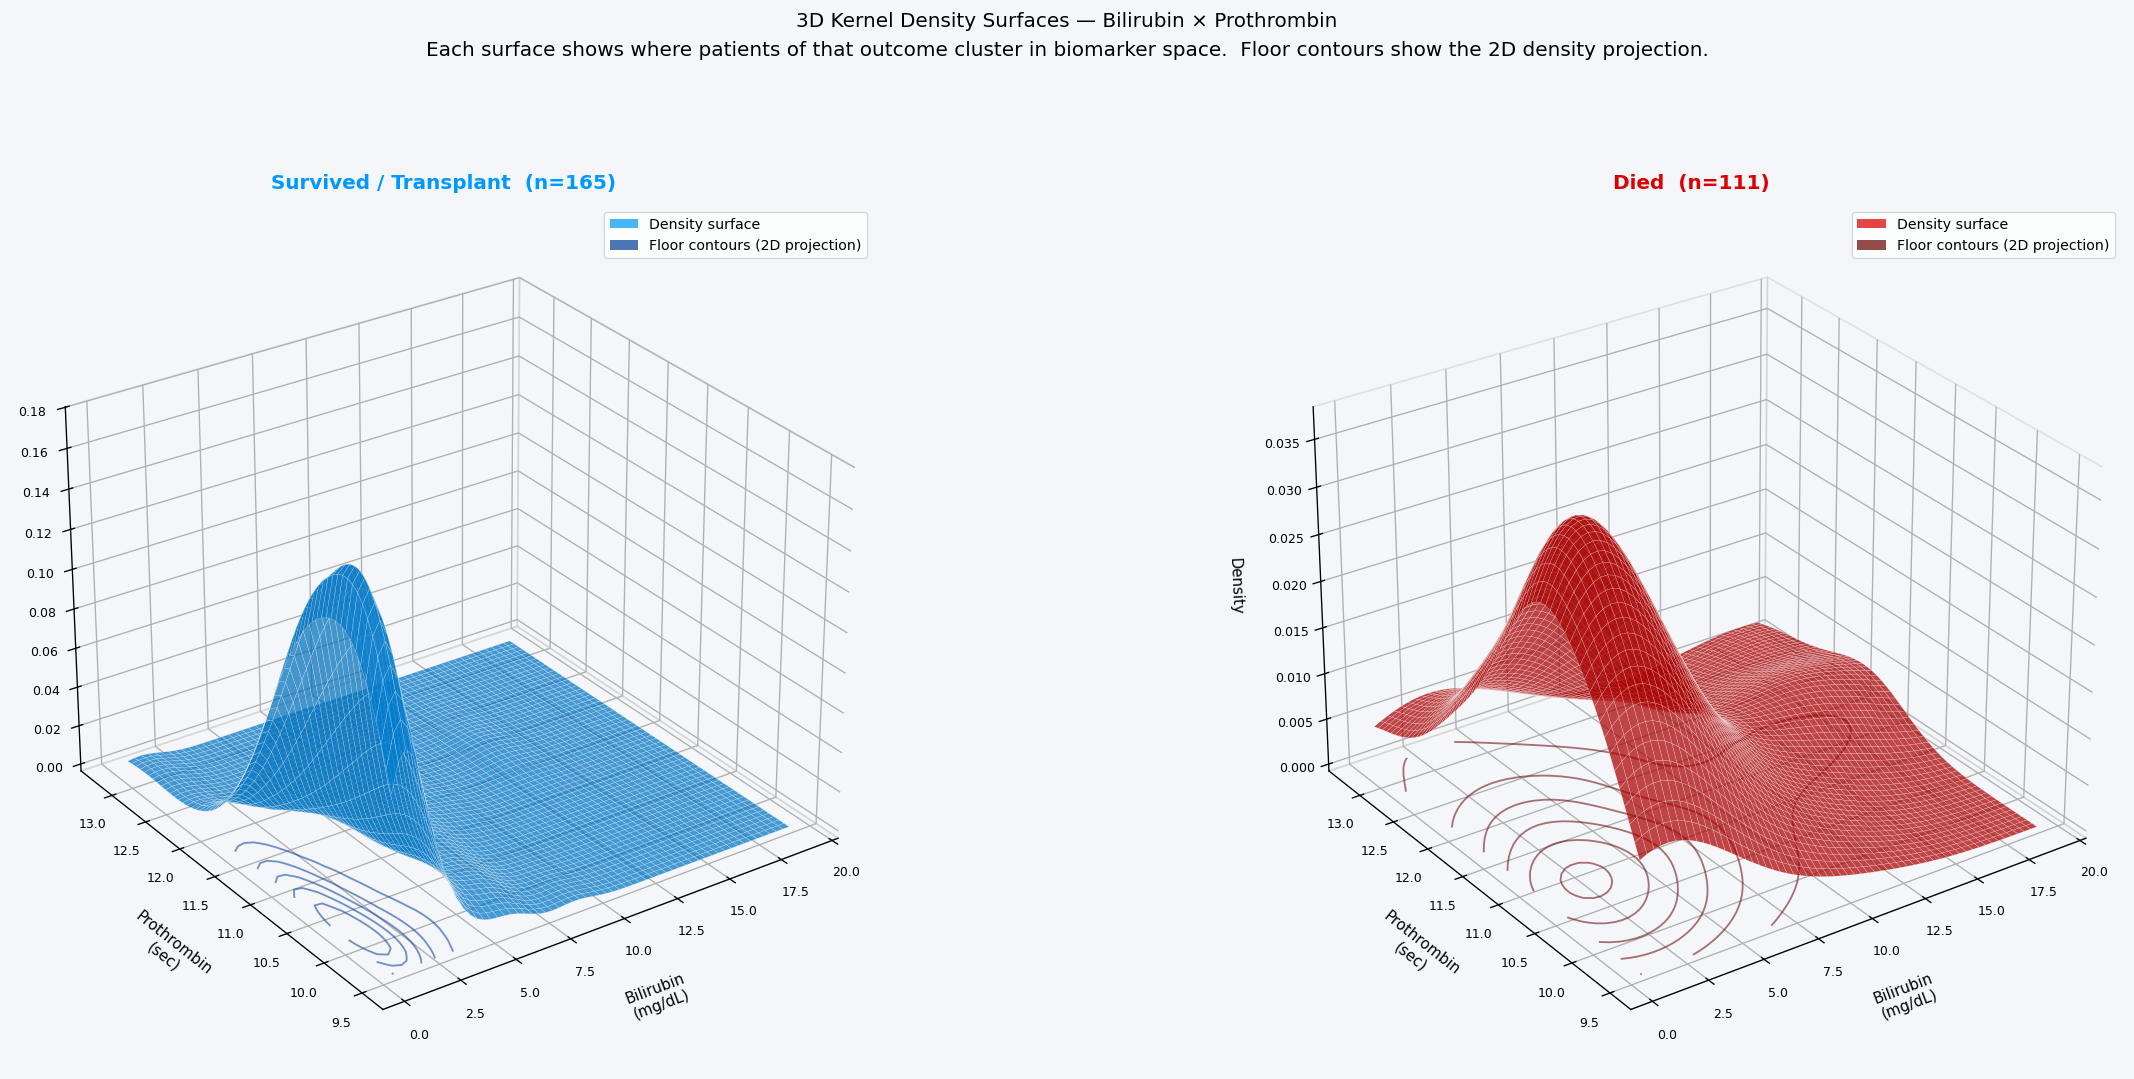

3D KDE surface figure saved.


In [20]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

feat_x_s = 'Bilirubin'
feat_y_s = 'Prothrombin'

df_surf = df[[feat_x_s, feat_y_s, TARGET_COL]].dropna()
surv_s  = df_surf[df_surf[TARGET_COL] == 0]
deceased_s  = df_surf[df_surf[TARGET_COL] == 1]

x_lo, x_hi = df_surf[feat_x_s].quantile(0.02), df_surf[feat_x_s].quantile(0.98)
y_lo, y_hi = df_surf[feat_y_s].quantile(0.02), df_surf[feat_y_s].quantile(0.98)

xi = np.linspace(x_lo, x_hi, 60)
yi = np.linspace(y_lo, y_hi, 60)
XI, YI = np.meshgrid(xi, yi)
grid   = np.vstack([XI.ravel(), YI.ravel()])

kde_surv = gaussian_kde(surv_s[[feat_x_s, feat_y_s]].values.T, bw_method=0.45)
kde_deceased = gaussian_kde(deceased_s[[feat_x_s, feat_y_s]].values.T, bw_method=0.45)
ZI_surv  = kde_surv(grid).reshape(XI.shape)
ZI_deceased  = kde_deceased(grid).reshape(XI.shape)

fig = plt.figure(figsize=(22, 9))
fig.patch.set_facecolor('#F4F6FA')

SURFACE_SPECS = [
    (f'Survived / Transplant  (n={len(surv_s)})', ZI_surv, COLOR_SURVIVED, '#003D99'),
    (f'Died  (n={len(deceased_s)})',                  ZI_deceased, COLOR_DIED,     '#6B0000'),
]

for idx, (group_title, ZI, surf_color, contour_color) in enumerate(SURFACE_SPECS):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    ax.set_facecolor('#F4F6FA')

    ax.plot_surface(XI, YI, ZI, color=surf_color, alpha=0.72,
                    rstride=1, cstride=1, linewidth=0.15,
                    edgecolor='white', antialiased=True)
    ax.contour(XI, YI, ZI, zdir='z', offset=0,
               colors=contour_color, alpha=0.55, levels=6, linewidths=1.1)

    ax.set_xlabel(f'{feat_x_s}\n(mg/dL)', fontsize=9, labelpad=12)
    ax.set_ylabel(f'{feat_y_s}\n(sec)',    fontsize=9, labelpad=12)
    ax.set_zlabel('Density',               fontsize=9, labelpad=10)
    ax.set_title(group_title, fontsize=12, fontweight='bold', pad=10, color=surf_color)
    ax.view_init(elev=28, azim=235)
    ax.tick_params(labelsize=7.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#CCCCCC')
    ax.yaxis.pane.set_edgecolor('#CCCCCC')
    ax.zaxis.pane.set_edgecolor('#CCCCCC')
    ax.grid(True, linestyle='--', linewidth=0.4, color='#DDDDDD')

    # Color-patch legend: what the surface and floor contours represent
    patch_handles = [
        Patch(facecolor=surf_color,    alpha=0.72, label='Density surface'),
        Patch(facecolor=contour_color, alpha=0.70, label='Floor contours (2D projection)'),
    ]
    legend = ax.legend(handles=patch_handles, fontsize=8.5, loc='upper right',
                       frameon=True, facecolor='white', edgecolor='#CCCCCC')
    legend.get_frame().set_linewidth(0.8)

plt.suptitle(
    f'3D Kernel Density Surfaces — {feat_x_s} × {feat_y_s}\n'
    'Each surface shows where patients of that outcome cluster in biomarker space.  '
    'Floor contours show the 2D density projection.',
    fontsize=12, y=1.02, linespacing=1.7
)
plt.tight_layout(pad=2.5)
plt.savefig('output/figures/3d_kde_surfaces.png', bbox_inches='tight')
plt.show()
print('3D KDE surface figure saved.')

---

## Section 17: 3D Bubble Plot — Biomarkers with Survival Time Encoded as Bubble Size

This chart adds a fourth data dimension by encoding N_Days (the number of days each patient was followed) as the size of each bubble. Larger bubbles represent patients who were followed for longer — whether they survived the full trial period or eventually deceased after a prolonged illness. The combination of position (three biomarkers) and bubble size (survival time) packs four clinical variables into a single 3D view, revealing patterns that would be hidden in any pairwise plot.

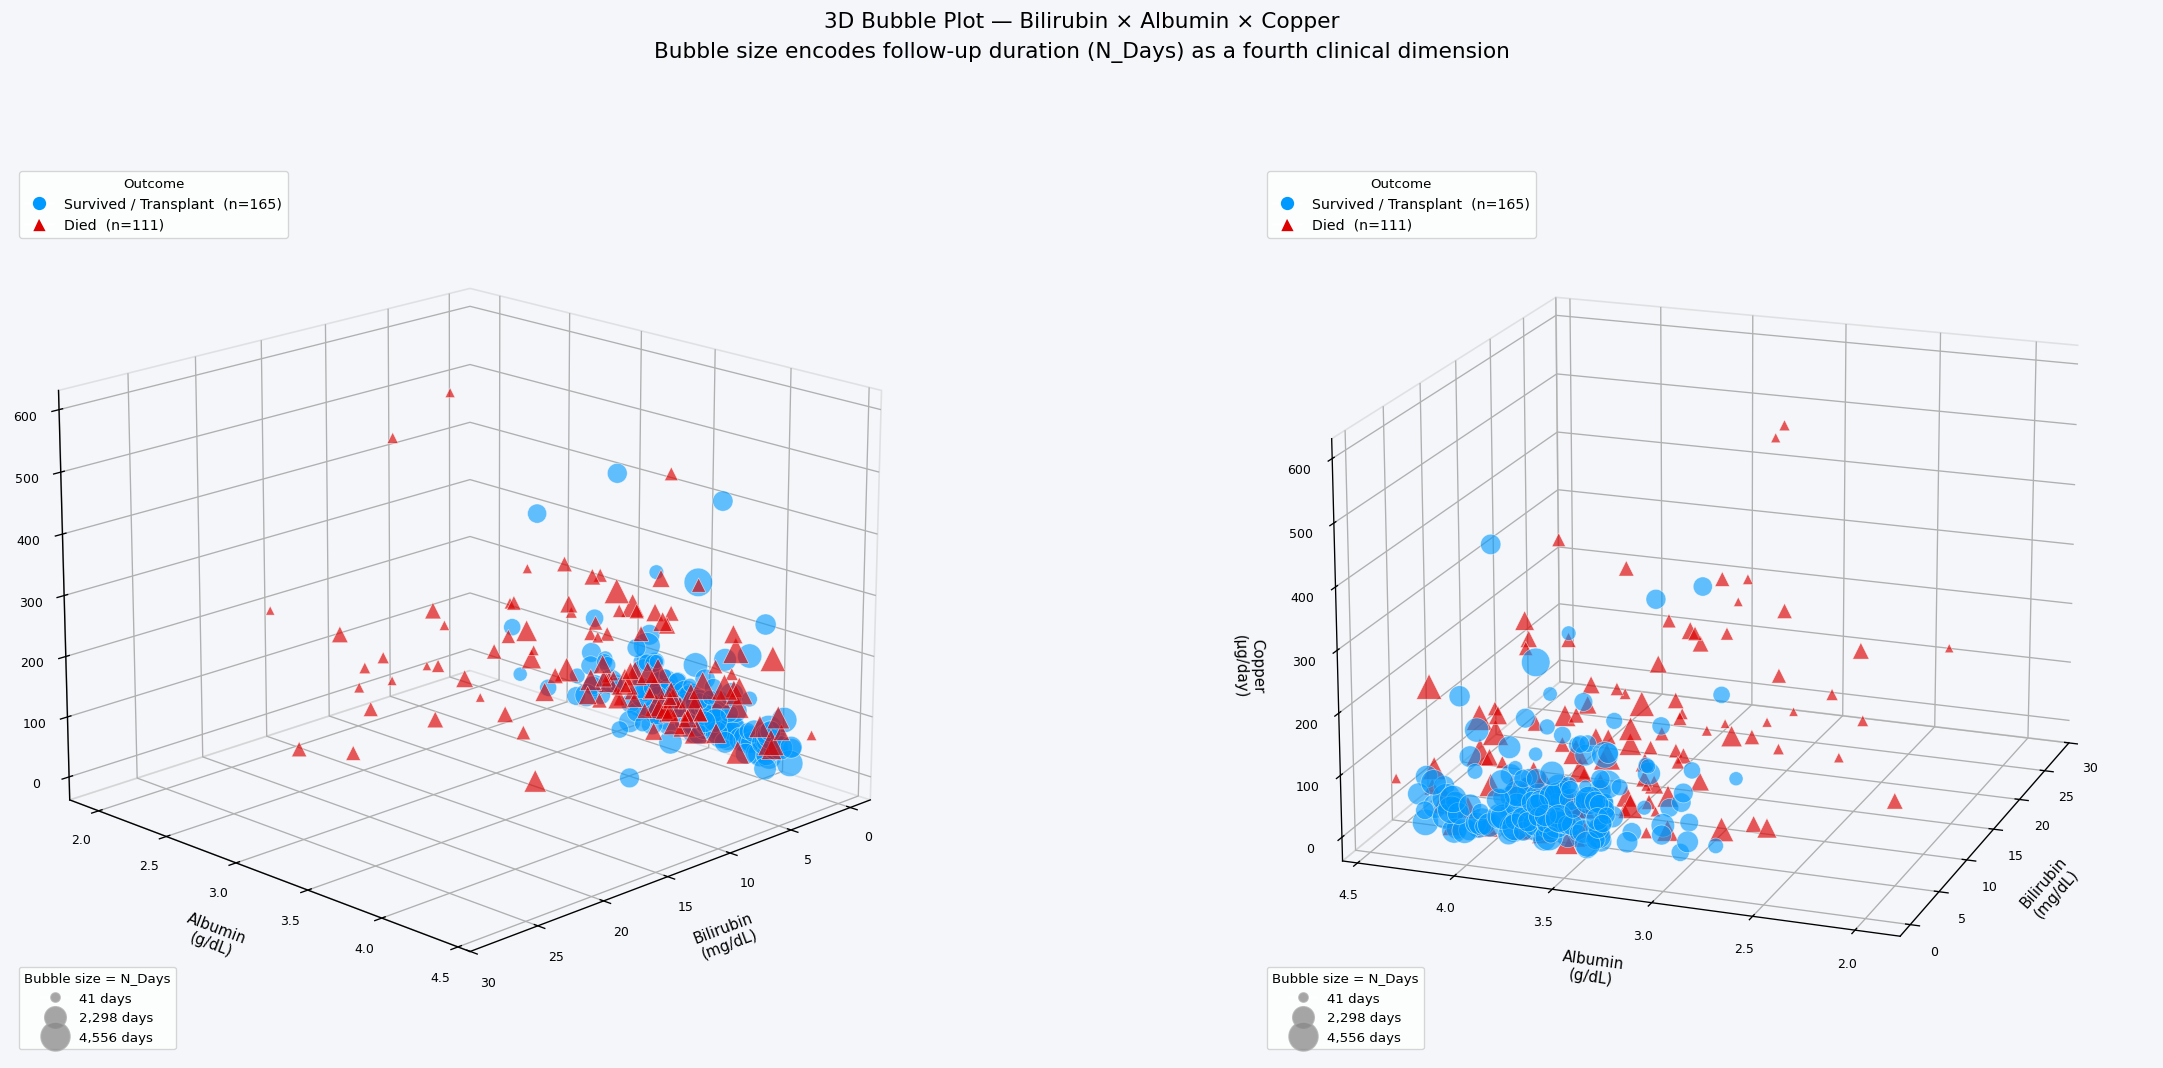

3D bubble plot saved.


In [21]:
from matplotlib.lines import Line2D

feat_a, feat_b, feat_c, feat_size = 'Bilirubin', 'Albumin', 'Copper', 'N_Days'

df_bub = df[[feat_a, feat_b, feat_c, feat_size, TARGET_COL]].dropna()
surv_b = df_bub[df_bub[TARGET_COL] == 0]
deceased_b = df_bub[df_bub[TARGET_COL] == 1]

# Use the global data range so all reference sizes scale consistently
N_LO  = df_bub[feat_size].min()
N_HI  = df_bub[feat_size].max()
S_MIN, S_MAX = 30, 300

def scale_size(series):
    return S_MIN + (series - N_LO) / (N_HI - N_LO) * (S_MAX - S_MIN)

surv_sizes = scale_size(surv_b[feat_size])
deceased_sizes = scale_size(deceased_b[feat_size])

VIEW_ANGLES_BUB = [(18, 45), (18, 200)]

fig = plt.figure(figsize=(22, 9))
fig.patch.set_facecolor('#F4F6FA')

for idx, (elev, azim) in enumerate(VIEW_ANGLES_BUB):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    ax.set_facecolor('#F4F6FA')

    ax.scatter(surv_b[feat_a], surv_b[feat_b], surv_b[feat_c],
               c=COLOR_SURVIVED, s=surv_sizes, alpha=0.60,
               edgecolors='white', linewidths=0.4, depthshade=True)
    ax.scatter(deceased_b[feat_a], deceased_b[feat_b], deceased_b[feat_c],
               c=COLOR_DIED, s=deceased_sizes, alpha=0.65,
               edgecolors='white', linewidths=0.4,
               marker='^', depthshade=True)

    ax.set_xlabel(f'{feat_a}\n(mg/dL)',  fontsize=9, labelpad=10)
    ax.set_ylabel(f'{feat_b}\n(g/dL)',   fontsize=9, labelpad=10)
    ax.set_zlabel(f'{feat_c}\n(µg/day)', fontsize=9, labelpad=10)
    ax.view_init(elev=elev, azim=azim)
    ax.tick_params(labelsize=7.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#CCCCCC')
    ax.yaxis.pane.set_edgecolor('#CCCCCC')
    ax.zaxis.pane.set_edgecolor('#CCCCCC')
    ax.grid(True, linestyle='--', linewidth=0.5, color='#DDDDDD')

    # Outcome legend (colour + marker shape)
    outcome_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_SURVIVED,
               markersize=9, label=f'Survived / Transplant  (n={len(surv_b)})',
               markeredgecolor='white'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_DIED,
               markersize=9, label=f'Died  (n={len(deceased_b)})',
               markeredgecolor='white'),
    ]

    # Bubble-size reference legend using actual min / median / max of N_Days
    ref_days   = [int(N_LO), int((N_LO + N_HI) / 2), int(N_HI)]
    ref_labels = [f'{d:,} days' for d in ref_days]
    ref_sizes  = [float(scale_size(pd.Series([float(d)])).iloc[0]) for d in ref_days]

    size_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#888888', alpha=0.75,
               markersize=np.sqrt(s), label=lbl,
               markeredgecolor='#AAAAAA')
        for s, lbl in zip(ref_sizes, ref_labels)
    ]

    # Two stacked legends: outcome (top-left) + bubble size (bottom-left)
    leg1 = ax.legend(handles=outcome_handles, fontsize=8.5, loc='upper left',
                     frameon=True, facecolor='white', edgecolor='#CCCCCC',
                     title='Outcome', title_fontsize=8)
    leg1.get_frame().set_linewidth(0.8)
    ax.add_artist(leg1)

    leg2 = ax.legend(handles=size_handles, fontsize=8, loc='lower left',
                     frameon=True, facecolor='white', edgecolor='#CCCCCC',
                     title='Bubble size = N_Days', title_fontsize=8)
    leg2.get_frame().set_linewidth(0.8)

plt.suptitle(
    f'3D Bubble Plot — {feat_a} × {feat_b} × {feat_c}\n'
    'Bubble size encodes follow-up duration (N_Days) as a fourth clinical dimension',
    fontsize=13, y=1.01, linespacing=1.6
)
plt.tight_layout(pad=2.5)
plt.savefig('output/figures/3d_bubble_biomarkers.png', bbox_inches='tight')
plt.show()
print('3D bubble plot saved.')